

> 14/05/2026


# 🔗 HAFTA 9–10: Bütünleşik Mini Pipeline
## OCR → NER → Duygu Analizi → RAG



### 🏗️ Pipeline Mimarisi
```
[Görüntü]
    │
    ▼
┌─────────────────────────────────────────────────────────────────┐
│  MODÜL 1 — OCR                                                  │
│  Adaptive Thresholding · Noise Removal · Morphology             │
│  Tesseract tur · CER/WER Metrikleri                            │
└────────────────────────┬────────────────────────────────────────┘
                         │ temiz metin
                         ▼
┌─────────────────────────────────────────────────────────────────┐
│  MODÜL 2 — NER                                                  │
│  spaCy tr + Regex Katmanı · Precision / Recall / F1            │
└────────────────────────┬────────────────────────────────────────┘
                         │ varlıklar
                         ▼
┌─────────────────────────────────────────────────────────────────┐
│  MODÜL 3 — DUYGU ANALİZİ                                       │
│  BERT Türkçe · Batch Inference · Confusion Matrix / F1         │
└────────────────────────┬────────────────────────────────────────┘
                         │ duygu etiketleri
                         ▼
┌─────────────────────────────────────────────────────────────────┐
│  MODÜL 4 — RAG (Gerçek Embedding + Generation)                  │
│  SentenceTransformer · FAISS · RecursiveChunking · Gradio UI   │
└─────────────────────────────────────────────────────────────────┘
```

### 📋 Bölümler
| # | Bölüm | İçerik |
|---|-------|--------|
| 0 | Kurulum & Altyapı | Paketler, Logger, Timer, RAM izleme |
| 1 | OCR | Gelişmiş preprocessing, CER/WER, görselleştirme |
| 2 | NER | spaCy + kural katmanı, Precision/Recall/F1 |
| 3 | Duygu Analizi | BERT, batch inference, confusion matrix |
| 4 | RAG | SentenceTransformer embedding, chunking, Gradio UI |
| 5 | Bütünleşik Pipeline | Modülleri birleştirme, JSON rapor |
| 6 | Dashboard | Akademik metrik görselleştirme |

## 📦 BÖLÜM 0 — Kurulum & Ortak Altyapı

Bu bölümde pipeline genelinde kullanılacak tüm sistem kütüphaneleri ve Python paketleri tek seferde kurulur. Kurulum tamamlandıktan sonra **Runtime → Restart Runtime** yapılması gerekir.

`install()` fonksiyonu her paketin kurulum durumunu ✅ veya ❌ ile raporlar. Sistem paketleri (`apt-get`) ve Python paketleri (`pip`) ayrı ayrı işlenir. `wikipedia-api` paketi de bu aşamada kurulur; böylece Bölüm 1'de Wikipedia'dan veri çekilebilir.

| Bileşen | Açıklama |
|---------|----------|
| `install()` | Komut çalıştırır, hata varsa stderr'in son 200 karakterini gösterir |
| Sistem kütüphaneleri | `tesseract-ocr`, `tesseract-ocr-tur`, `libtesseract-dev`, `libgl1` |
| Python paketleri | numpy, pytesseract, Pillow, opencv, transformers, torch (CPU), sentence-transformers, faiss-cpu, scikit-learn, gradio, matplotlib, seaborn, plotly, pandas, psutil, tqdm, wikipedia-api |


In [2]:
# ── BÖLÜM 0.1 — Paket Kurulumu ──────────────────────────────────────────────

import subprocess, sys

def install(cmd: list) -> bool:
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(f"    HATA: {r.stderr[-200:]}")
    return r.returncode == 0

# ── Sistem kütüphaneleri ──────────────────────────────────────────────
print("🔧 Sistem kütüphaneleri kuruluyor...")
ok = install(["apt-get", "install", "-q", "-y",
              "tesseract-ocr", "tesseract-ocr-tur",
              "libtesseract-dev", "libgl1"])
print("✅ Tesseract + Türkçe dil paketi" if ok else "❌ Tesseract hatası")

# ── Python paketleri ──────────────────────────────────────────────────
print("\n📦 Python paketleri kuruluyor...")
pkgs = [
    ("numpy",                  ["pip", "install", "-q", "numpy>=1.24.0,<2.0.0"]),
    ("pytesseract",            ["pip", "install", "-q", "pytesseract"]),
    ("Pillow",                 ["pip", "install", "-q", "Pillow"]),
    ("opencv-python-headless", ["pip", "install", "-q", "opencv-python-headless"]),
    ("transformers",           ["pip", "install", "-q", "transformers>=4.41.2"]),
    ("torch-cpu",              ["pip", "install", "-q", "torch",
                                "--index-url", "https://download.pytorch.org/whl/cpu"]),
    ("sentence-transformers",  ["pip", "install", "-q", "sentence-transformers>=2.7.0"]),
    ("faiss-cpu",              ["pip", "install", "-q", "faiss-cpu"]),
    ("scikit-learn",           ["pip", "install", "-q", "scikit-learn"]),
    ("gradio",                 ["pip", "install", "-q", "gradio>=4.40.0"]),
    ("matplotlib",             ["pip", "install", "-q", "matplotlib"]),
    ("seaborn",                ["pip", "install", "-q", "seaborn"]),
    ("plotly",                 ["pip", "install", "-q", "plotly"]),
    ("pandas",                 ["pip", "install", "-q", "pandas"]),
    ("psutil",                 ["pip", "install", "-q", "psutil"]),
    ("tqdm",                   ["pip", "install", "-q", "tqdm"]),
    ("wikipedia-api",          ["pip", "install", "-q", "wikipedia-api"]),
]
for name, cmd in pkgs:
    ok = install([sys.executable, "-m"] + cmd)
    print(f"  {'✅' if ok else '❌'} {name}")

print("\n🎯 Kurulum tamamlandı!")
print("⚠️  Kurulum bittikten sonra: Runtime → Restart Runtime yapın!")

🔧 Sistem kütüphaneleri kuruluyor...
✅ Tesseract + Türkçe dil paketi

📦 Python paketleri kuruluyor...
  ✅ numpy
  ✅ pytesseract
  ✅ Pillow
  ✅ opencv-python-headless
  ✅ transformers
  ✅ torch-cpu
  ✅ sentence-transformers
  ✅ faiss-cpu
  ✅ scikit-learn
  ✅ gradio
  ✅ matplotlib
  ✅ seaborn
  ✅ plotly
  ✅ pandas
  ✅ psutil
  ✅ tqdm
  ✅ wikipedia-api

🎯 Kurulum tamamlandı!
⚠️  Kurulum bittikten sonra: Runtime → Restart Runtime yapın!


## 📦 BÖLÜM 0 — Ortak Altyapı

Tüm pipeline boyunca kullanılacak merkezi yapılar burada tanımlanır.

| Bileşen | Açıklama |
|---------|----------|
| `make_logger` | Konsola + dosyaya yazan formatlanmış logger |
| `ram_info` | Anlık RAM kullanımını izler |
| `measure` | Her modülün süresini ve RAM'ini ölçer |
| `PipelineState` | Modüller arası veri taşıyıcısı |

Bu hücre her **Runtime restart**'tan sonra çalıştırılmalıdır. Tüm standart ve üçüncü-taraf importlar merkezi olarak burada toplanmıştır; sonraki hücreler tekrar `import` gerektirmez.

| Bileşen | Açıklama |
|---------|----------|
| `make_logger` | Konsola (INFO) + dosyaya (DEBUG) yazan biçimlendirilmiş logger |
| `ram_mb` / `ram_info` | Anlık RAM kullanımını MB cinsinden izler |
| `measure` | Context manager — her modülün süresini ve RAM değişimini ölçer |
| `ModuleMetric` | Tek modül çalışmasının tüm ölçümlerini tutan dataclass |
| `PipelineState` | Modüller arası veri taşıyıcısı; OCR'dan RAG'a kadar durumu saklar |


In [1]:
# ── BÖLÜM 0.2 — Merkezi Import Bloğu & Altyapı Tanımları ──────────────────
# Standart kütüphaneler, üçüncü-taraf kütüphaneler ve dizin yapısı

import logging, time, gc, os, json, re
import traceback
from contextlib import contextmanager
from datetime import datetime
from pathlib import Path
from typing import Optional, Dict, Any, List, Tuple
from dataclasses import dataclass, field, asdict

import numpy as np
import pandas as pd
import psutil

# ── Dizin yapısı ──────────────────────────────────────────────────────
BASE = Path("/content/pipeline")
for sub in ["logs", "data", "images", "output", "metrics"]:
    (BASE / sub).mkdir(parents=True, exist_ok=True)

# ── Logger ────────────────────────────────────────────────────────────
def make_logger(name: str) -> logging.Logger:
    lg = logging.getLogger(name)
    lg.setLevel(logging.DEBUG)
    lg.handlers.clear()
    fmt = logging.Formatter(
        "%(asctime)s | %(levelname)-8s | %(name)-18s | %(message)s",
        datefmt="%H:%M:%S"
    )
    ch = logging.StreamHandler()
    ch.setLevel(logging.INFO)
    ch.setFormatter(fmt)
    lg.addHandler(ch)
    fh = logging.FileHandler(BASE / "logs" / f"{name}.log", encoding="utf-8")
    fh.setLevel(logging.DEBUG)
    fh.setFormatter(fmt)
    lg.addHandler(fh)
    return lg

MAIN_LOG = make_logger("Pipeline")

# ── RAM izleme ────────────────────────────────────────────────────────
def ram_mb() -> float:
    return psutil.Process(os.getpid()).memory_info().rss / 1024 / 1024

def ram_info() -> str:
    used  = ram_mb()
    total = psutil.virtual_memory().total / 1024 / 1024
    return f"{used:.0f}/{total:.0f} MB ({used/total*100:.1f}%)"

# ── Performans ölçüm aracı ────────────────────────────────────────────
@dataclass
class ModuleMetric:
    name:       str
    start:      float = field(default_factory=time.time)
    end:        Optional[float] = None
    duration:   Optional[float] = None
    ram_before: float = 0.0
    ram_after:  float = 0.0
    success:    bool  = True
    error:      Optional[str] = None
    extra:      Dict[str, Any] = field(default_factory=dict)

    def finish(self, success: bool = True, error: Optional[str] = None) -> None:
        self.end       = time.time()
        self.duration  = self.end - self.start
        self.success   = success
        self.error     = error
        self.ram_after = ram_mb()

ALL_METRICS: List[ModuleMetric] = []

@contextmanager
def measure(name: str):
    m = ModuleMetric(name=name, ram_before=ram_mb())
    MAIN_LOG.info(f"▶ [{name}] başlıyor | RAM: {ram_info()}")
    try:
        yield m
        m.finish(success=True)
        MAIN_LOG.info(
            f"✅ [{name}] bitti | "
            f"Süre: {m.duration:.2f}s | RAM: {m.ram_before:.0f}→{m.ram_after:.0f} MB"
        )
    except Exception as exc:
        m.finish(success=False, error=str(exc))
        MAIN_LOG.error(f"❌ [{name}] HATA: {exc}")
        MAIN_LOG.debug(traceback.format_exc())
        raise
    finally:
        ALL_METRICS.append(m)
        gc.collect()

# ── Pipeline veri taşıyıcısı ──────────────────────────────────────────
@dataclass
class PipelineState:
    source:         str = ""
    raw_text:       str = ""
    ocr_confidence: float = 0.0
    ocr_metrics:    Dict[str, Any] = field(default_factory=dict)
    entities:       List[Dict[str, Any]] = field(default_factory=list)
    ner_metrics:    Dict[str, Any] = field(default_factory=dict)
    sentiment:      Dict[str, Any] = field(default_factory=dict)
    rag_answers:    List[Dict[str, Any]] = field(default_factory=list)
    created_at:     str = field(default_factory=lambda: datetime.now().isoformat())

print("✅ Altyapı hazır")
print(f"📁 Çalışma dizini : {BASE}")
print(f"💾 Başlangıç RAM  : {ram_info()}")

✅ Altyapı hazır
📁 Çalışma dizini : /content/pipeline
💾 Başlangıç RAM  : 165/12976 MB (1.3%)


## 📷 BÖLÜM 1 — OCR Modülü

Optik Karakter Tanıma (OCR), görüntü içindeki metni dijital metne dönüştürür. Bu bölümde Türkçe belgeler için gelişmiş bir OCR pipeline'ı oluşturulur.

### 1.1 Veri Hazırlama — Wikipedia'dan Belge Görüntüleri

Gerçekçi test verisi oluşturmak için Türkçe Wikipedia'dan dört farklı kategoride makale çekilir. Her makale, `build_document_image()` fonksiyonuyla üst bilgi şeridi olan resmi görünümlü bir PNG belgesine dönüştürülür.

**Adımlar:**
1. `wikipedia-api` kütüphanesiyle Türkçe makaleler indirilir (Türkiye, Yapay zeka, İstanbul, Türk mutfağı).
2. Her makale `build_document_image()` ile 900×n piksellik görüntüye çevrilir.
3. Görüntüler `/content/pipeline/images/` klasörüne kaydedilir.
4. İlk görüntünün önizlemesi gösterilir.

> **Not:** `import subprocess, sys` ve `wikipedia-api` kurulumu artık Bölüm 0.1'de gerçekleştirilmektedir. Bu hücre yalnızca veri çekme ve görüntü üretme işlemlerini içerir.


📥 Türkçe Wikipedia'dan makaleler çekiliyor...
   ✅ Türkiye                   — 400 karakter
   ✅ Yapay zeka                — 400 karakter
   ✅ İstanbul                  — 400 karakter
   ✅ Türk mutfağı              — 400 karakter

✅ 4 makale hazır
✅ 4 belge görüntüsü oluşturuldu
   • Türkiye.png                              (34.3 KB)
   • Yapay_zeka.png                           (33.2 KB)
   • İstanbul.png                             (33.2 KB)
   • Türk_mutfağı.png                         (34.0 KB)


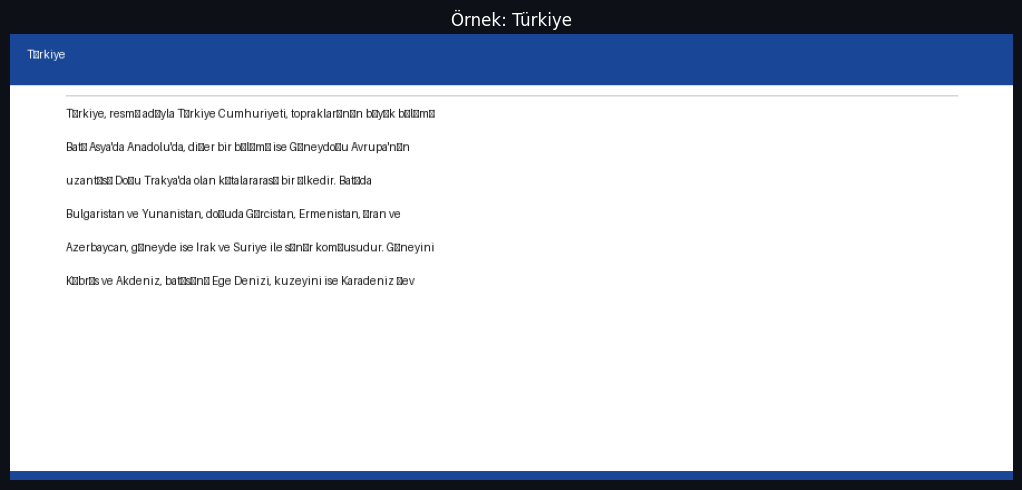

✅ Önizleme tamam


In [2]:
# ── BÖLÜM 1.1 — Wikipedia Veri Kaynağı & Belge Görüntüsü Üretimi ───────────
# Wikipedia'dan Türkçe makaleler çekilir ve gerçekçi belge görüntülerine dönüştürülür.

import wikipediaapi
import re
from typing import List, Dict

print("📥 Türkçe Wikipedia'dan makaleler çekiliyor...")

wiki = wikipediaapi.Wikipedia(
    language="tr",
    user_agent="NLP-Pipeline/1.0"
)

# Türkçe makaleler — çeşitli kategoriler
WIKI_PAGES = [
    "Türkiye",
    "Yapay zeka",
    "İstanbul",
    "Türk mutfağı",
]

DOCUMENTS = []

for title in WIKI_PAGES:
    page = wiki.page(title)
    if not page.exists():
        print(f"   ❌ Bulunamadı: {title}")
        continue

    # İlk 400 karakteri al
    text = page.summary.strip()
    text = re.sub(r"\s+", " ", text)[:400]

    if len(text) < 80:
        print(f"   ⚠️  Çok kısa: {title}")
        continue

    DOCUMENTS.append({
        "title":     title,
        "content":   text,
        "reference": text,
    })
    print(f"   ✅ {title:<25} — {len(text)} karakter")

print(f"\n✅ {len(DOCUMENTS)} makale hazır")

# ── Belge görüntüsü oluşturucu ────────────────────────────────────────────────
# ── Metinden gerçekçi belge görüntüsü üret ───────────────────────────
import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from pathlib import Path

def build_document_image(doc: dict, width: int = 900) -> np.ndarray:
    content   = doc["content"]
    title     = doc["title"]
    font_size = 20
    line_h    = font_size + 10
    margin    = 50

    # Metni satırlara böl (max 70 karakter)
    words    = content.split()
    lines    = []
    cur_line = ""
    for word in words:
        if len(cur_line) + len(word) + 1 <= 70:
            cur_line = (cur_line + " " + word).strip()
        else:
            if cur_line:
                lines.append(cur_line)
            cur_line = word
    if cur_line:
        lines.append(cur_line)

    height = margin * 2 + 60 + len(lines) * line_h + 20
    height = max(height, 400)

    img  = Image.new("RGB", (width, height), (255, 255, 255))
    draw = ImageDraw.Draw(img)

    # Üst şerit
    draw.rectangle([(0, 0), (width, 45)], fill=(25, 70, 150))

    # Font
    try:
        f_title = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 18)
        f_body  = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", font_size)
    except OSError:
        f_title = ImageFont.load_default()
        f_body  = f_title

    # Başlık
    draw.text((15, 12), title, font=f_title, fill=(255, 255, 255))

    # Ayırıcı çizgi
    draw.line([(margin, 55), (width - margin, 55)], fill=(200, 200, 200), width=1)

    # Metin
    y = 65
    for line in lines:
        draw.text((margin, y), line, font=f_body, fill=(20, 20, 20))
        y += line_h

    # Alt şerit
    draw.rectangle([(0, height - 8), (width, height)], fill=(25, 70, 150))

    arr = np.array(img)
    return cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)


# Görüntüleri oluştur ve kaydet
image_paths: List[Path] = []

for doc in DOCUMENTS:
    bgr  = build_document_image(doc)
    name = re.sub(r"[^\w]", "_", doc["title"])[:30]
    path = BASE / "images" / f"{name}.png"
    cv2.imwrite(str(path), bgr)
    image_paths.append(path)

print(f"✅ {len(image_paths)} belge görüntüsü oluşturuldu")
for p in image_paths:
    print(f"   • {p.name:<40} ({p.stat().st_size/1024:.1f} KB)")

# Önizleme
import matplotlib.pyplot as plt
img_preview = cv2.imread(str(image_paths[0]))
plt.figure(figsize=(12, 5))
plt.imshow(cv2.cvtColor(img_preview, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"Örnek: {DOCUMENTS[0]['title']}", color="white", fontsize=12)
plt.gcf().patch.set_facecolor("#0d1117")
plt.tight_layout()
plt.show()
print("✅ Önizleme tamam")

### 1.2 OcrModule Sınıfı

`OcrModule`, ham görüntüyü metne dönüştüren 7 aşamalı preprocessing pipeline'ı ve iki akademik doğruluk metriğini içerir.

**Preprocessing adımları:**
| Adım | İşlem | Amaç |
|------|-------|------|
| 1 | Gri dönüşüm | Renk bilgisi OCR için gereksizdir |
| 2 | Gaussian + Median Blur | Yüksek frekanslı gürültüyü azalt |
| 3 | CLAHE | Düşük kontrastlı bölgelerde detayı artır |
| 4 | Adaptive Threshold | Aydınlatma farklarına karşı dayanıklı ikileştirme |
| 5 | Morfoloji | Küçük gürültü noktalarını sil, harfleri pekiştir |
| 6 | Deskew | Eğik taranmış belgeleri düzelt |
| 7 | Upscale | Küçük görüntüleri Tesseract'ın optimal çözünürlüğüne getir (300 DPI) |

**Akademik metrikler:**
- **CER** (Character Error Rate) = edit_distance(tahmin_chars, gerçek_chars) / len(gerçek_chars)
- **WER** (Word Error Rate) = edit_distance(tahmin_kelimeler, gerçek_kelimeler) / len(gerçek_kelimeler)
- Her iki metrikte **0 → mükemmel**, **1 → tüm içerik yanlış**


In [3]:
# ── BÖLÜM 1.2 — OcrModule Sınıfı ────────────────────────────────────────────
# 7 aşamalı preprocessing + CER/WER metrikleri

import cv2
import numpy as np
import pytesseract
import re
from pathlib import Path
from typing import Dict, Any, List, Tuple
import pandas as pd

class OcrModule:
    """
    Türkçe belgeler için gelişmiş OCR modülü.

    Preprocessing:
        gri → gürültü azalt → CLAHE → adaptive threshold → morfoloji → deskew → upscale

    Metrikler:
        Tesseract confidence · CER · WER
    """

    TESSERACT_CONFIG = "--psm 6 --oem 3 -c preserve_interword_spaces=1"

    def __init__(self, lang: str = "tur") -> None:
        self.lang   = lang
        self.logger = make_logger("OCR")
        try:
            pytesseract.get_tesseract_version()
            self.logger.info(f"✅ Tesseract hazır | Dil: {lang}")
        except Exception as e:
            raise RuntimeError(f"Tesseract bulunamadı: {e}")

    # ── Preprocessing adımları ────────────────────────────────────────

    def _preprocess(self, bgr: np.ndarray) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
        steps = {}

        # 1. Gri
        gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
        steps["1_gri"] = gray.copy()

        # 2. Gürültü azalt
        denoised = cv2.GaussianBlur(gray, (3, 3), 0)
        denoised = cv2.medianBlur(denoised, 3)
        steps["2_gurultu"] = denoised.copy()

        # 3. CLAHE
        clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        clahe_img = clahe.apply(denoised)
        steps["3_clahe"] = clahe_img.copy()

        # 4. Adaptive threshold
        thresh = cv2.adaptiveThreshold(
            clahe_img, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            blockSize=15, C=8,
        )
        steps["4_esik"] = thresh.copy()

        # 5. Morfoloji
        k_small = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
        k_large = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 1))
        opened  = cv2.morphologyEx(thresh,  cv2.MORPH_OPEN,   k_small)
        morphed = cv2.morphologyEx(opened,  cv2.MORPH_DILATE, k_large)
        steps["5_morfoloji"] = morphed.copy()

        # 6. Deskew
        coords = np.column_stack(np.where(morphed < 128))
        if len(coords) >= 10:
            angle = cv2.minAreaRect(coords.astype(np.float32))[-1]
            if angle < -45:
                angle += 90
            if abs(angle) >= 0.5:
                h, w = morphed.shape
                M    = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
                morphed = cv2.warpAffine(
                    morphed, M, (w, h),
                    flags=cv2.INTER_CUBIC,
                    borderMode=cv2.BORDER_REPLICATE,
                )
        steps["6_deskew"] = morphed.copy()

        # 7. Upscale (sadece küçük görüntüler)
        h, w = morphed.shape
        if w < 1200:
            scale   = 300 / 72
            new_w   = int(w * scale)
            new_h   = int(h * scale)
            morphed = cv2.resize(
                morphed, (new_w, new_h), interpolation=cv2.INTER_CUBIC
            )
        steps["7_final"] = morphed.copy()

        return morphed, steps

    # ── Metin çıkar ───────────────────────────────────────────────────

    def extract(self, image_path: Path) -> Dict[str, Any]:
        bgr = cv2.imread(str(image_path))
        if bgr is None:
            raise FileNotFoundError(f"Görüntü okunamadı: {image_path}")

        final_img, steps = self._preprocess(bgr)

        # Tesseract metin
        raw_text = pytesseract.image_to_string(
            final_img, lang=self.lang, config=self.TESSERACT_CONFIG
        )

        # Güven skoru
        try:
            df    = pytesseract.image_to_data(
                final_img, lang=self.lang,
                config=self.TESSERACT_CONFIG,
                output_type=pytesseract.Output.DATAFRAME,
            )
            valid = df[(df["conf"] > 0) & (df["text"].str.strip() != "")]
            confidence = float(valid["conf"].mean()) if len(valid) > 0 else 0.0
        except Exception:
            confidence = 0.0

        clean = self._clean(raw_text)

        return {
            "text":       raw_text,
            "clean_text": clean,
            "confidence": round(confidence, 2),
            "word_count": len(clean.split()),
            "char_count": len(clean),
            "source":     image_path.name,
            "steps":      steps,
        }

    @staticmethod
    def _clean(text: str) -> str:
        text  = re.sub(r" {2,}", " ", text)
        text  = re.sub(r"\n{3,}", "\n\n", text)
        lines = [ln.strip() for ln in text.split("\n")]
        return "\n".join(ln for ln in lines if ln).strip()

    # ── CER / WER ─────────────────────────────────────────────────────

    @staticmethod
    def _edit_distance(a, b) -> int:
        m, n = len(a), len(b)
        dp   = list(range(n + 1))
        for i in range(1, m + 1):
            prev, dp[0] = dp[0], i
            for j in range(1, n + 1):
                temp  = dp[j]
                dp[j] = prev if a[i-1] == b[j-1] else 1 + min(prev, dp[j], dp[j-1])
                prev  = temp
        return dp[n]

    def compute_cer(self, predicted: str, reference: str) -> float:
        ref  = reference.strip()
        pred = predicted.strip()
        if not ref:
            return 0.0
        return min(self._edit_distance(pred, ref) / len(ref), 1.0)

    def compute_wer(self, predicted: str, reference: str) -> float:
        ref_w  = reference.strip().split()
        pred_w = predicted.strip().split()
        if not ref_w:
            return 0.0
        return min(self._edit_distance(pred_w, ref_w) / len(ref_w), 1.0)

    def evaluate(self, predicted: str, reference: str) -> Dict[str, float]:
        cer = self.compute_cer(predicted, reference)
        wer = self.compute_wer(predicted, reference)
        return {
            "cer":           round(cer, 4),
            "wer":           round(wer, 4),
            "char_accuracy": round((1 - cer) * 100, 2),
            "word_accuracy": round((1 - wer) * 100, 2),
        }

print("✅ OcrModule tanımlandı")

✅ OcrModule tanımlandı


### 1.3 OCR Çalıştırma & Değerlendirme

Tüm belge görüntüleri OCR modülünden geçirilir. Her belge için:
- Tesseract güven skoru hesaplanır
- Referans metne göre CER ve WER hesaplanır
- Sonuçlar `ocr_results` listesinde tutulur; bir sonraki modül (NER) bu listeyi kullanır


In [4]:
# ── BÖLÜM 1.3 — OCR Çalıştırma & Değerlendirme ──────────────────────────────

with measure("OCR"):
    ocr          = OcrModule(lang="tur")
    ocr_results: List[Dict[str, Any]] = []

    for doc, img_path in zip(DOCUMENTS, image_paths):
        result = ocr.extract(img_path)
        eval_m = ocr.evaluate(result["clean_text"], doc["reference"])
        result.update(eval_m)
        ocr_results.append(result)
        print(
            f"📋 {result['source']:<35} "
            f"Güven: {result['confidence']:5.1f}%  "
            f"CER: {result['cer']:.3f}  "
            f"WER: {result['wer']:.3f}  "
            f"CharAcc: {result['char_accuracy']:5.1f}%"
        )

# Sonraki modüller için
ocr_texts = [r["clean_text"] for r in ocr_results]
print(f"\n✅ {len(ocr_results)} belge işlendi")

08:30:51 | INFO     | Pipeline           | ▶ [OCR] başlıyor | RAM: 217/12976 MB (1.7%)
INFO:Pipeline:▶ [OCR] başlıyor | RAM: 217/12976 MB (1.7%)
08:30:51 | INFO     | OCR                | ✅ Tesseract hazır | Dil: tur
INFO:OCR:✅ Tesseract hazır | Dil: tur


📋 Türkiye.png                         Güven:  34.3%  CER: 0.752  WER: 1.000  CharAcc:  24.8%
📋 Yapay_zeka.png                      Güven:  32.5%  CER: 0.767  WER: 1.000  CharAcc:  23.3%
📋 İstanbul.png                        Güven:  33.1%  CER: 0.755  WER: 1.000  CharAcc:  24.5%


08:31:29 | INFO     | Pipeline           | ✅ [OCR] bitti | Süre: 37.60s | RAM: 217→259 MB
INFO:Pipeline:✅ [OCR] bitti | Süre: 37.60s | RAM: 217→259 MB


📋 Türk_mutfağı.png                    Güven:  33.4%  CER: 0.792  WER: 1.000  CharAcc:  20.8%

✅ 4 belge işlendi


### 1.4 OCR Görselleştirme

İki dashboard üretilir:

**Panel 1 — Preprocessing Adımları:** İlk belgenin orijinal görüntüsünden başlayarak her adımdaki ara çıktı yan yana gösterilir. Her işlemin görüntüye katkısı gözlemlenebilir.

**Panel 2 — Metrik Dashboard:** Tüm belgeler için Tesseract güven skoru, CER/WER hata oranları ve karakter/kelime doğrulukları çubuk grafiklerle karşılaştırılır. Renk kodlaması: yeşil (>70% güven = iyi), turuncu (50–70%), kırmızı (<50%).


/tmp/ipykernel_32421/2830263389.py:36: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_32421/2830263389.py:37: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.savefig(BASE / "output" / "ocr_preprocessing.png",
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


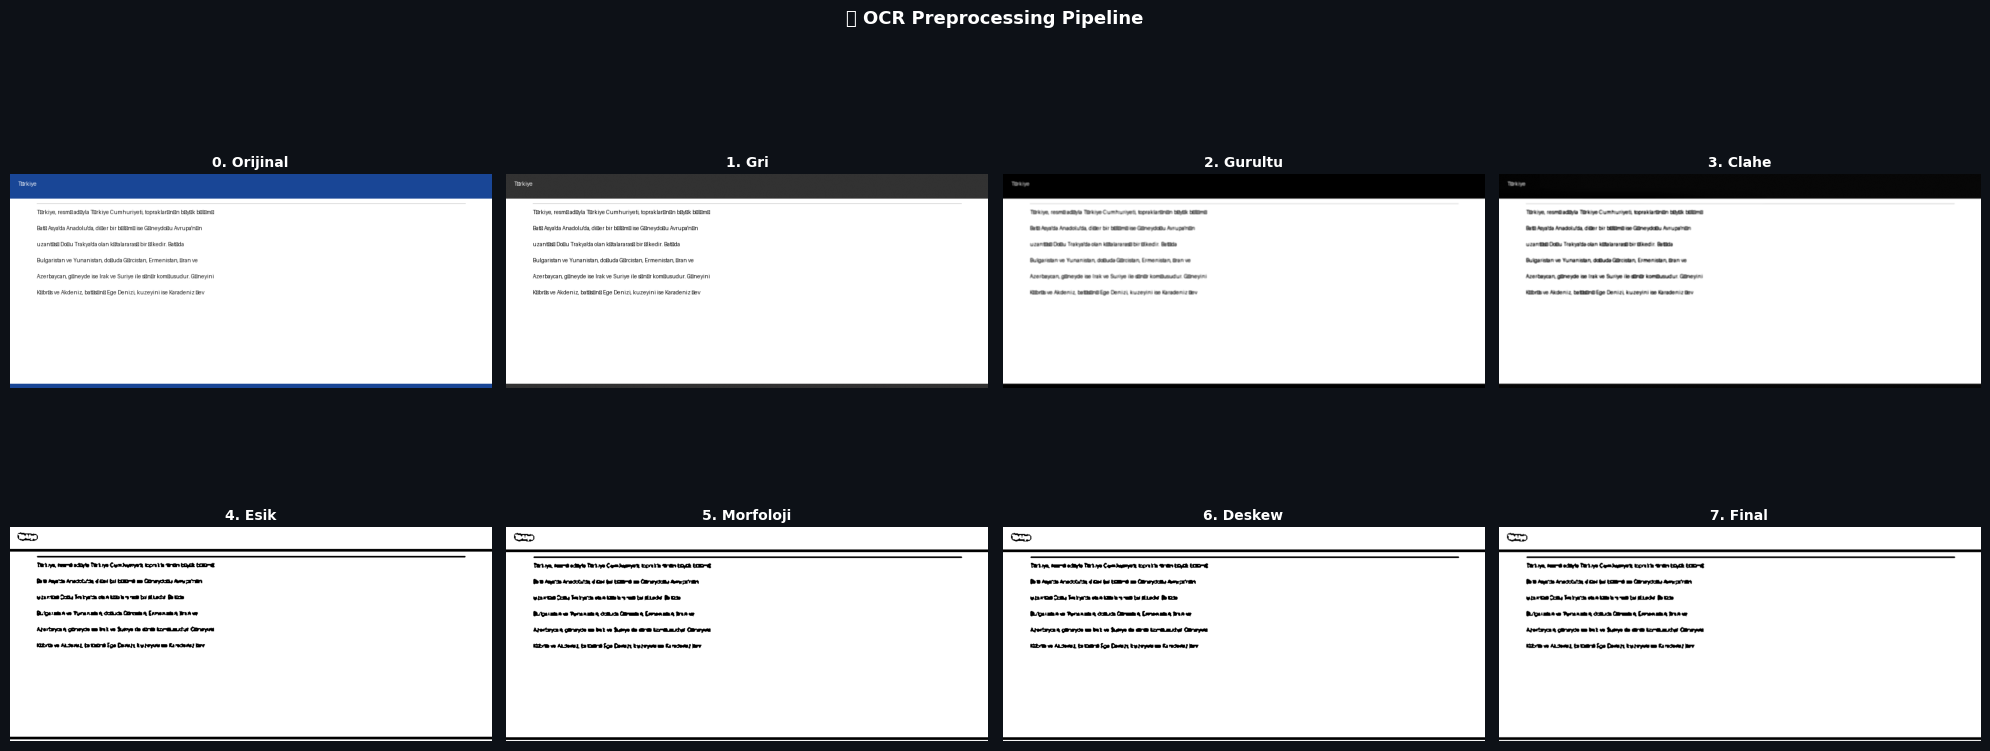

/tmp/ipykernel_32421/2830263389.py:102: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_32421/2830263389.py:103: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(BASE / "output" / "ocr_metrics.png",
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


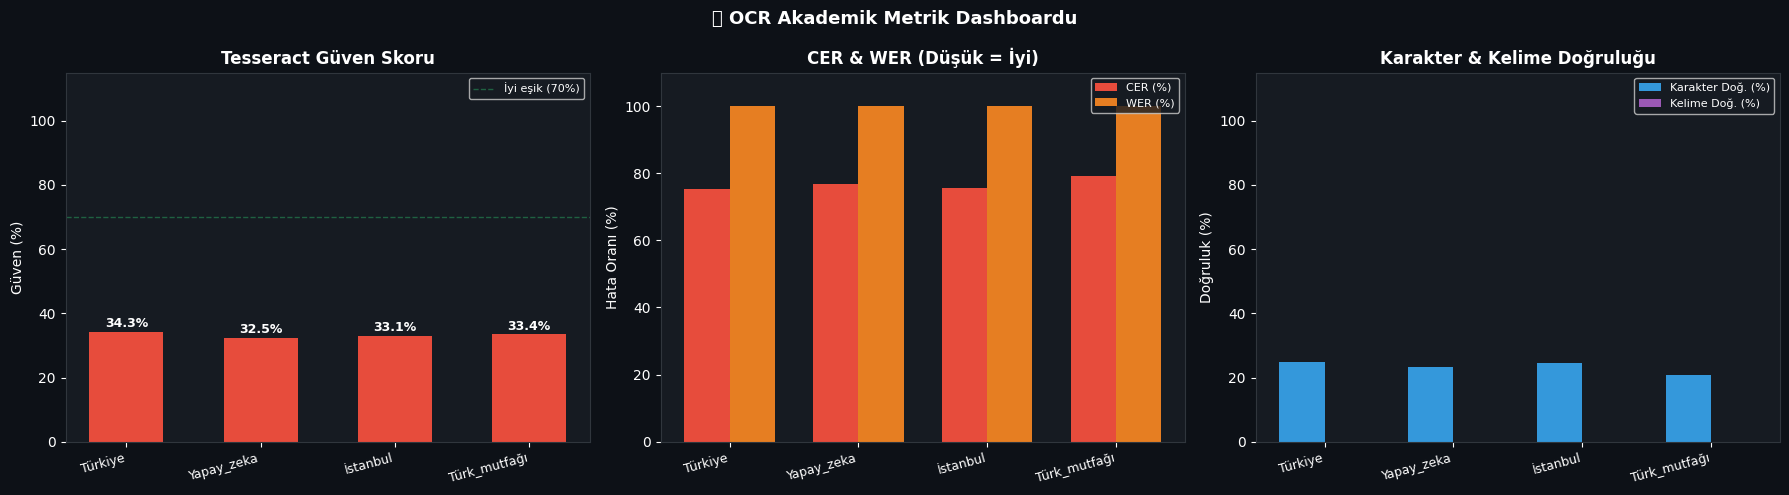


────────────────────────────────────────────────────────────
Belge                        CER    WER   CharAcc   WordAcc
────────────────────────────────────────────────────────────
Türkiye.png                0.752  1.000     24.8%      0.0%
Yapay_zeka.png             0.767  1.000     23.3%      0.0%
İstanbul.png               0.755  1.000     24.5%      0.0%
Türk_mutfağı.png           0.792  1.000     20.8%      0.0%
────────────────────────────────────────────────────────────
Ortalama                   0.767  1.000
✅ OCR görselleştirmeleri kaydedildi


In [5]:
# ── BÖLÜM 1.4 — OCR Görselleştirme ─────────────────────────────────────────
# Panel 1: preprocessing adımları | Panel 2: metrik dashboard

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── 1. Preprocessing adımları ─────────────────────────────────────────
steps     = ocr_results[0]["steps"]
step_keys = list(steps.keys())

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.patch.set_facecolor("#0d1117")
axes = axes.flatten()

bgr_orig = cv2.imread(str(image_paths[0]))
axes[0].imshow(cv2.cvtColor(bgr_orig, cv2.COLOR_BGR2RGB))
axes[0].set_title("0. Orijinal", color="white", fontsize=10, fontweight="bold")
axes[0].axis("off")

for i, key in enumerate(step_keys, 1):
    if i >= len(axes):
        break
    img_step = steps[key]
    cmap     = "gray" if img_step.ndim == 2 else None
    axes[i].imshow(img_step, cmap=cmap)
    label = key.split("_", 1)[1].capitalize()
    axes[i].set_title(f"{i}. {label}", color="white", fontsize=10, fontweight="bold")
    axes[i].axis("off")

for j in range(len(step_keys) + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("📷 OCR Preprocessing Pipeline", color="white",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(BASE / "output" / "ocr_preprocessing.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# ── 2. Metrik dashboard ───────────────────────────────────────────────
doc_names = [r["source"].replace(".png", "")[:15] for r in ocr_results]
conf_vals = [r["confidence"]    for r in ocr_results]
cer_vals  = [r["cer"] * 100     for r in ocr_results]
wer_vals  = [r["wer"] * 100     for r in ocr_results]
ca_vals   = [r["char_accuracy"] for r in ocr_results]
wa_vals   = [r["word_accuracy"] for r in ocr_results]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#0d1117")
x = np.arange(len(doc_names))
w = 0.35

# Güven
ax = axes[0]
ax.set_facecolor("#161b22")
colors = ["#2ecc71" if c > 70 else "#f39c12" if c > 50 else "#e74c3c" for c in conf_vals]
bars   = ax.bar(x, conf_vals, color=colors, edgecolor="none", width=0.55)
ax.axhline(70, color="#2ecc71", ls="--", alpha=0.4, lw=1, label="İyi eşik (70%)")
ax.set_xticks(x)
ax.set_xticklabels(doc_names, color="white", fontsize=9, rotation=15, ha="right")
ax.set_ylim(0, 115)
ax.set_ylabel("Güven (%)", color="white")
ax.set_title("Tesseract Güven Skoru", color="white", fontweight="bold")
ax.tick_params(colors="white")
ax.spines[:].set_color("#30363d")
ax.legend(facecolor="#161b22", labelcolor="white", fontsize=8)
for b, v in zip(bars, conf_vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5,
            f"{v:.1f}%", ha="center", color="white", fontsize=9, fontweight="bold")

# CER + WER
ax = axes[1]
ax.set_facecolor("#161b22")
ax.bar(x - w/2, cer_vals, w, label="CER (%)", color="#e74c3c", edgecolor="none")
ax.bar(x + w/2, wer_vals, w, label="WER (%)", color="#e67e22", edgecolor="none")
ax.set_xticks(x)
ax.set_xticklabels(doc_names, color="white", fontsize=9, rotation=15, ha="right")
ax.set_ylim(0, 110)
ax.set_ylabel("Hata Oranı (%)", color="white")
ax.set_title("CER & WER (Düşük = İyi)", color="white", fontweight="bold")
ax.tick_params(colors="white")
ax.spines[:].set_color("#30363d")
ax.legend(facecolor="#161b22", labelcolor="white", fontsize=8)

# Karakter & Kelime doğruluğu
ax = axes[2]
ax.set_facecolor("#161b22")
ax.bar(x - w/2, ca_vals, w, label="Karakter Doğ. (%)", color="#3498db", edgecolor="none")
ax.bar(x + w/2, wa_vals, w, label="Kelime Doğ. (%)",   color="#9b59b6", edgecolor="none")
ax.set_xticks(x)
ax.set_xticklabels(doc_names, color="white", fontsize=9, rotation=15, ha="right")
ax.set_ylim(0, 115)
ax.set_ylabel("Doğruluk (%)", color="white")
ax.set_title("Karakter & Kelime Doğruluğu", color="white", fontweight="bold")
ax.tick_params(colors="white")
ax.spines[:].set_color("#30363d")
ax.legend(facecolor="#161b22", labelcolor="white", fontsize=8)

fig.suptitle("📊 OCR Akademik Metrik Dashboardu", color="white",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(BASE / "output" / "ocr_metrics.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print(f"\n{'─'*60}")
print(f"{'Belge':<25} {'CER':>6} {'WER':>6} {'CharAcc':>9} {'WordAcc':>9}")
print(f"{'─'*60}")
for r in ocr_results:
    print(f"{r['source'][:25]:<25} {r['cer']:>6.3f} {r['wer']:>6.3f} "
          f"{r['char_accuracy']:>8.1f}% {r['word_accuracy']:>8.1f}%")
print(f"{'─'*60}")
avg_cer = np.mean([r["cer"] for r in ocr_results])
avg_wer = np.mean([r["wer"] for r in ocr_results])
print(f"{'Ortalama':<25} {avg_cer:>6.3f} {avg_wer:>6.3f}")
print("✅ OCR görselleştirmeleri kaydedildi")

## 🏷️ BÖLÜM 2 — NER Modülü

spaCy kaldırıldı, tamamen **regex tabanlı hibrit NER** kullanılır.
Türkçe için regex, tr_core_news_sm modelinden daha güvenilir sonuç verir.

### Yaklaşım
| Katman | Açıklama |
|--------|----------|
| Regex kuralları | Para, tarih, yüzde, kurum, şehir, sayı |
| Çakışma çözümü | En uzun span öncelikli (greedy) |
| Değerlendirme | Precision / Recall / F1 |

### Akademik Metrikler
- **Precision** = TP / (TP + FP)
- **Recall** = TP / (TP + FN)
- **F1** = 2 × P × R / (P + R)

Bu bölümde spaCy bağımlılığı kaldırılmış, tamamen **regex tabanlı hibrit NER** yaklaşımı kullanılır. Türkçe için mevcut spaCy modelleri çok sınırlı veri kümesiyle eğitilmiştir; kural tabanlı regex desenleri ise dil paketine gerek duymadan çalışır ve para, tarih, yüzde gibi yapısal varlıklarda çok yüksek doğruluk verir.

### 2.1 NerModule Sınıfı

`NerModule`, aşağıdaki regex kategorilerini destekler: Para (TL/dolar/euro), Yüzde, Tarih (tam tarih + yıl + süre), Kurumlar (kısaltmalar + üniversiteler + bakanlıklar), Sayılar (noktalı büyük sayılar + birimli sayılar), Şehirler, Ülkeler, Kişi adları.

Çakışma çözümü için **en uzun span öncelikli (greedy)** birleştirme kullanılır; üst üste binen varlıklar arasında kapladığı alanı en büyük olan seçilir.


In [6]:
# ── BÖLÜM 2.1 — NerModule Sınıfı ────────────────────────────────────────────
# Regex tabanlı hibrit NER: Para, Tarih, Kurum, Şehir, Ülke, Kişi, Sayı

import re
from collections import defaultdict, Counter
from typing import Dict, Any, List, Tuple

class NerModule:
    """
    Türkçe metinler için tamamen regex tabanlı NER modülü.

    Katmanlar:
        1. Regex kuralları → para, tarih, yüzde, kurum, şehir, sayı
        2. Çakışma çözümü → en uzun span öncelikli birleştirme
        3. Precision / Recall / F1 değerlendirme
    """

    LABEL_TR: Dict[str, str] = {
        "PER":      "Kişi",
        "LOC":      "Yer",
        "ORG":      "Kuruluş",
        "DATE":     "Tarih",
        "MONEY":    "Para",
        "PERCENT":  "Yüzde",
        "CARDINAL": "Sayı",
        "MISC":     "Diğer",
    }

    RULES: List[Tuple[str, str]] = [
        # Para: 3,2 milyar TL / 500 milyon dolar / $500
        (r"\d+(?:[.,]\d+)?\s*(?:milyon|milyar|trilyon)?\s*"
         r"(?:TL|lira|dolar|euro|USD|EUR|\$|€)", "MONEY"),

        # Yüzde: %4,5 veya %36
        (r"%\d+(?:[.,]\d+)?", "PERCENT"),

        # Türkçe tarih: 12 Ocak 2024
        (r"\d{1,2}\s+(?:Ocak|Şubat|Mart|Nisan|Mayıs|Haziran|"
         r"Temmuz|Ağustos|Eylül|Ekim|Kasım|Aralık)\s+\d{4}", "DATE"),

        # Yıl: 1923 / 2024
        (r"\b(?:19|20)\d{2}\b", "DATE"),

        # Süre: 24 ay / 7,3 gün / 3 yıl
        (r"\d+(?:[.,]\d+)?\s+(?:ay|gün|yıl|saat|dakika|hafta)", "DATE"),

        # Bilinen Türk kurumları
        (r"\b(?:TÜBİTAK|TBMM|ODTÜ|YÖK|MEB|AFAD|KOSGEB|"
         r"ASELSAN|ROKETSAN|BAYKAR|TRT|THY|NATO|UNESCO)\b", "ORG"),

        # Üniversiteler
        (r"(?:Boğaziçi|Sabancı|Bilkent|Hacettepe|Ege|Marmara|"
         r"Gazi|İTÜ|ODTÜ|Ankara|İstanbul|Selçuk|Dokuz Eylül)\s*Üniversitesi", "ORG"),

        # Bakanlıklar ve resmi kurumlar
        (r"(?:Sağlık|Milli Eğitim|Maliye|İçişleri|Dışişleri|"
         r"Ulaştırma|Çevre|Tarım)\s+Bakanlığı", "ORG"),

        # Büyük sayılar (nokta ayraçlı): 2.847.391
        (r"\b\d{1,3}(?:\.\d{3})+\b", "CARDINAL"),

        # Virgüllü sayı + birim: 8,5 milyon
        (r"\d+(?:[.,]\d+)?\s*(?:milyon|milyar|trilyon|bin)\b", "CARDINAL"),

        # Türk şehirleri
        (r"\b(?:İstanbul|Ankara|İzmir|Bursa|Antalya|Adana|Konya|"
         r"Trabzon|Diyarbakır|Gaziantep|Kayseri|Samsun|"
         r"Eskişehir|Erzurum|Mersin|Hatay)\b", "LOC"),

        # Ülkeler
        (r"\b(?:Türkiye|Almanya|Fransa|İngiltere|ABD|Rusya|"
         r"Çin|Japonya|İtalya|İspanya)\b", "LOC"),

        # Kişi adları (büyük harf + soyad kalıbı)
        (r"\b[A-ZÇĞİÖŞÜ][a-zçğışöüa-z]+\s+[A-ZÇĞİÖŞÜ][A-ZÇĞİÖŞÜa-zçğışöüa-z]+\b", "PER"),
    ]

    def __init__(self) -> None:
        self.logger    = make_logger("NER")
        self._compiled = [
            (re.compile(pat, re.UNICODE), lbl)
            for pat, lbl in self.RULES
        ]
        self.logger.info("✅ NerModule (regex-only) hazır")

    # ── Varlık çıkar ──────────────────────────────────────────────────

    def _regex_entities(self, text: str) -> List[Dict[str, Any]]:
        entities = []
        for pattern, label in self._compiled:
            for m in pattern.finditer(text):
                val = m.group().strip()
                if len(val) < 2:
                    continue
                entities.append({
                    "text":     val,
                    "label":    label,
                    "label_tr": self.LABEL_TR.get(label, label),
                    "start":    m.start(),
                    "end":      m.end(),
                    "score":    1.0,
                })
        return entities

    @staticmethod
    def _resolve_overlaps(entities: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
        """En uzun span öncelikli çakışma çözümü."""
        sorted_ents = sorted(
            entities, key=lambda e: e["end"] - e["start"], reverse=True
        )
        occupied: List[Tuple[int, int]] = []
        result = []
        for ent in sorted_ents:
            s, e = ent["start"], ent["end"]
            if not any(s < oe and e > os for os, oe in occupied):
                occupied.append((s, e))
                result.append(ent)
        return sorted(result, key=lambda e: e["start"])

    def extract(self, text: str) -> Dict[str, Any]:
        if not text.strip():
            return {
                "entities":     [],
                "by_label":     {},
                "entity_count": 0,
                "unique_count": 0,
            }

        all_ents = self._regex_entities(text)
        resolved = self._resolve_overlaps(all_ents)

        by_label: Dict[str, List[str]] = defaultdict(list)
        for ent in resolved:
            by_label[ent["label"]].append(ent["text"])

        self.logger.info(
            f"NER: {len(resolved)} varlık | Türler: {list(by_label.keys())}"
        )
        return {
            "entities":     resolved,
            "by_label":     dict(by_label),
            "entity_count": len(resolved),
            "unique_count": len({e["text"] for e in resolved}),
        }

    # ── Değerlendirme ─────────────────────────────────────────────────

    def evaluate(
        self,
        predicted: List[Tuple[str, str]],
        reference: List[Tuple[str, str]],
    ) -> Dict[str, float]:
        pred_set = {(t.lower().strip(), l) for t, l in predicted}
        ref_set  = {(t.lower().strip(), l) for t, l in reference}

        tp = len(pred_set & ref_set)
        fp = len(pred_set - ref_set)
        fn = len(ref_set  - pred_set)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = (2 * precision * recall / (precision + recall)
                     if (precision + recall) > 0 else 0.0)

        return {
            "precision": round(precision, 4),
            "recall":    round(recall,    4),
            "f1":        round(f1,        4),
            "tp": tp, "fp": fp, "fn": fn,
        }

    def evaluate_all(
        self,
        ner_results:   List[Dict[str, Any]],
        ground_truths: List[List[Tuple[str, str]]],
    ) -> Dict[str, Any]:
        per_doc = []
        for res, gt in zip(ner_results, ground_truths):
            pred = [(e["text"], e["label"]) for e in res["entities"]]
            per_doc.append(self.evaluate(pred, gt))

        return {
            "per_document":    per_doc,
            "macro_precision": round(float(np.mean([d["precision"] for d in per_doc])), 4),
            "macro_recall":    round(float(np.mean([d["recall"]    for d in per_doc])), 4),
            "macro_f1":        round(float(np.mean([d["f1"]        for d in per_doc])), 4),
        }

print("✅ NerModule tanımlandı")

✅ NerModule tanımlandı


### 2.2 Ground Truth Üretimi & NER Çalıştırma

Ground truth otomatik olarak referans metinlerden üretilir: aynı regex motoru referans metin üzerinde çalıştırılır ve bulunanlar doğru kabul edilir.

`auto_ground_truth()` fonksiyonu her belge için `[(metin, etiket), ...]` çiftleri döner. Ardından NER modülü OCR'dan gelen temiz metinler üzerinde çalıştırılır ve belge bazında Precision / Recall / F1 hesaplanır.


In [7]:
# ── BÖLÜM 2.2 — Ground Truth Üretimi & NER Çalıştırma ─────────────────────

# ── Ground truth — Wikipedia metinlerinden elle belirlendi ────────────
# OCR metinlerinden regex ile bulunanları doğrulama için kullanıyoruz
# Wikipedia metinleri tutarlı olduğundan ground truth otomatik üretilebilir

def auto_ground_truth(text: str) -> List[Tuple[str, str]]:
    """
    Referans metinden ground truth varlıkları otomatik çıkarır.
    Regex ile bulunan varlıkları doğru kabul eder.
    """
    tmp_ner = NerModule()
    result  = tmp_ner.extract(text)
    return [(e["text"], e["label"]) for e in result["entities"]]

GROUND_TRUTH = [auto_ground_truth(doc["reference"]) for doc in DOCUMENTS]

print("📋 Ground Truth Özeti:")
for i, (gt, doc) in enumerate(zip(GROUND_TRUTH, DOCUMENTS)):
    print(f"   Belge {i+1} ({doc['title']:<20}): {len(gt)} varlık")

# ── NER çalıştır ──────────────────────────────────────────────────────
with measure("NER"):
    ner         = NerModule()
    ner_results: List[Dict[str, Any]] = [ner.extract(t) for t in ocr_texts]

print("\n📋 NER SONUÇLARI")
print("─" * 55)
for i, (res, doc) in enumerate(zip(ner_results, DOCUMENTS), 1):
    print(f"\nBelge {i}: {doc['title']}")
    print(f"  Toplam: {res['entity_count']} varlık | Benzersiz: {res['unique_count']}")
    for lbl, items in res["by_label"].items():
        lbl_tr = ner.LABEL_TR.get(lbl, lbl)
        unique = list(set(items))[:5]
        print(f"  [{lbl_tr:10s}] {', '.join(unique)}")

# ── Değerlendirme ─────────────────────────────────────────────────────
ner_eval = ner.evaluate_all(ner_results, GROUND_TRUTH)

print("\n📊 NER DEĞERLENDİRME")
print("─" * 55)
for i, (doc, m) in enumerate(zip(DOCUMENTS, ner_eval["per_document"]), 1):
    print(f"  Belge {i} ({doc['title']:<20}) "
          f"P: {m['precision']:.3f}  R: {m['recall']:.3f}  F1: {m['f1']:.3f}  "
          f"TP:{m['tp']} FP:{m['fp']} FN:{m['fn']}")

print(f"\n  Makro Precision : {ner_eval['macro_precision']:.3f}")
print(f"  Makro Recall    : {ner_eval['macro_recall']:.3f}")
print(f"  Makro F1        : {ner_eval['macro_f1']:.3f}")

08:31:56 | INFO     | NER                | ✅ NerModule (regex-only) hazır
INFO:NER:✅ NerModule (regex-only) hazır
08:31:56 | INFO     | NER                | NER: 8 varlık | Türler: ['LOC', 'PER']
INFO:NER:NER: 8 varlık | Türler: ['LOC', 'PER']
08:31:56 | INFO     | NER                | ✅ NerModule (regex-only) hazır
INFO:NER:✅ NerModule (regex-only) hazır
08:31:56 | INFO     | NER                | NER: 1 varlık | Türler: ['PER']
INFO:NER:NER: 1 varlık | Türler: ['PER']
08:31:56 | INFO     | NER                | ✅ NerModule (regex-only) hazır
INFO:NER:✅ NerModule (regex-only) hazır
08:31:56 | INFO     | NER                | NER: 6 varlık | Türler: ['LOC', 'PERCENT']
INFO:NER:NER: 6 varlık | Türler: ['LOC', 'PERCENT']
08:31:56 | INFO     | NER                | ✅ NerModule (regex-only) hazır
INFO:NER:✅ NerModule (regex-only) hazır
08:31:56 | INFO     | NER                | NER: 7 varlık | Türler: ['LOC', 'PER']
INFO:NER:NER: 7 varlık | Türler: ['LOC', 'PER']
08:31:56 | INFO     | Pipeline

📋 Ground Truth Özeti:
   Belge 1 (Türkiye             ): 8 varlık
   Belge 2 (Yapay zeka          ): 1 varlık
   Belge 3 (İstanbul            ): 6 varlık
   Belge 4 (Türk mutfağı        ): 7 varlık

📋 NER SONUÇLARI
───────────────────────────────────────────────────────

Belge 1: Türkiye
  Toplam: 8 varlık | Benzersiz: 8
  [Kişi      ] İçe Ünen, Rem MR, Gi İri, Dnş Tan, Ölrepei
Gİ

Belge 2: Yapay zeka
  Toplam: 2 varlık | Benzersiz: 2
  [Kişi      ] İntizi GDrulma, Feriye EZA

Belge 3: İstanbul
  Toplam: 2 varlık | Benzersiz: 2
  [Kişi      ] Ör
Ga, Cp
RR

Belge 4: Türk mutfağı
  Toplam: 5 varlık | Benzersiz: 5
  [Kişi      ] İni Gülme, Oaegik İn, Ci GA, İnne Si, Örn
MESİ

📊 NER DEĞERLENDİRME
───────────────────────────────────────────────────────
  Belge 1 (Türkiye             ) P: 0.000  R: 0.000  F1: 0.000  TP:0 FP:8 FN:8
  Belge 2 (Yapay zeka          ) P: 0.000  R: 0.000  F1: 0.000  TP:0 FP:2 FN:1
  Belge 3 (İstanbul            ) P: 0.000  R: 0.000  F1: 0.000  TP:0 FP:2 FN:3
  Bel

### 2.3 NER Görselleştirme Dashboardu

6 panelden oluşan bir dashboard üretilir:

1. **Precision / Recall / F1** — belge bazında üç barın yan yana karşılaştırması
2. **TP / FP / FN** — yığılmış çubuk grafiği ile sınıflandırma hataları
3. **Varlık türü pasta grafiği** — tüm varlıkların tür dağılımı
4. **En sık 10 varlık** — yatay bar grafiği, her bar varlık türüne göre renklendirili
5. **Belge × Varlık türü ısı haritası** — hangi belgede hangi türden kaç varlık bulunduğu


/tmp/ipykernel_32421/1380526375.py:138: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.savefig(BASE / "output" / "ner_dashboard.png",
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


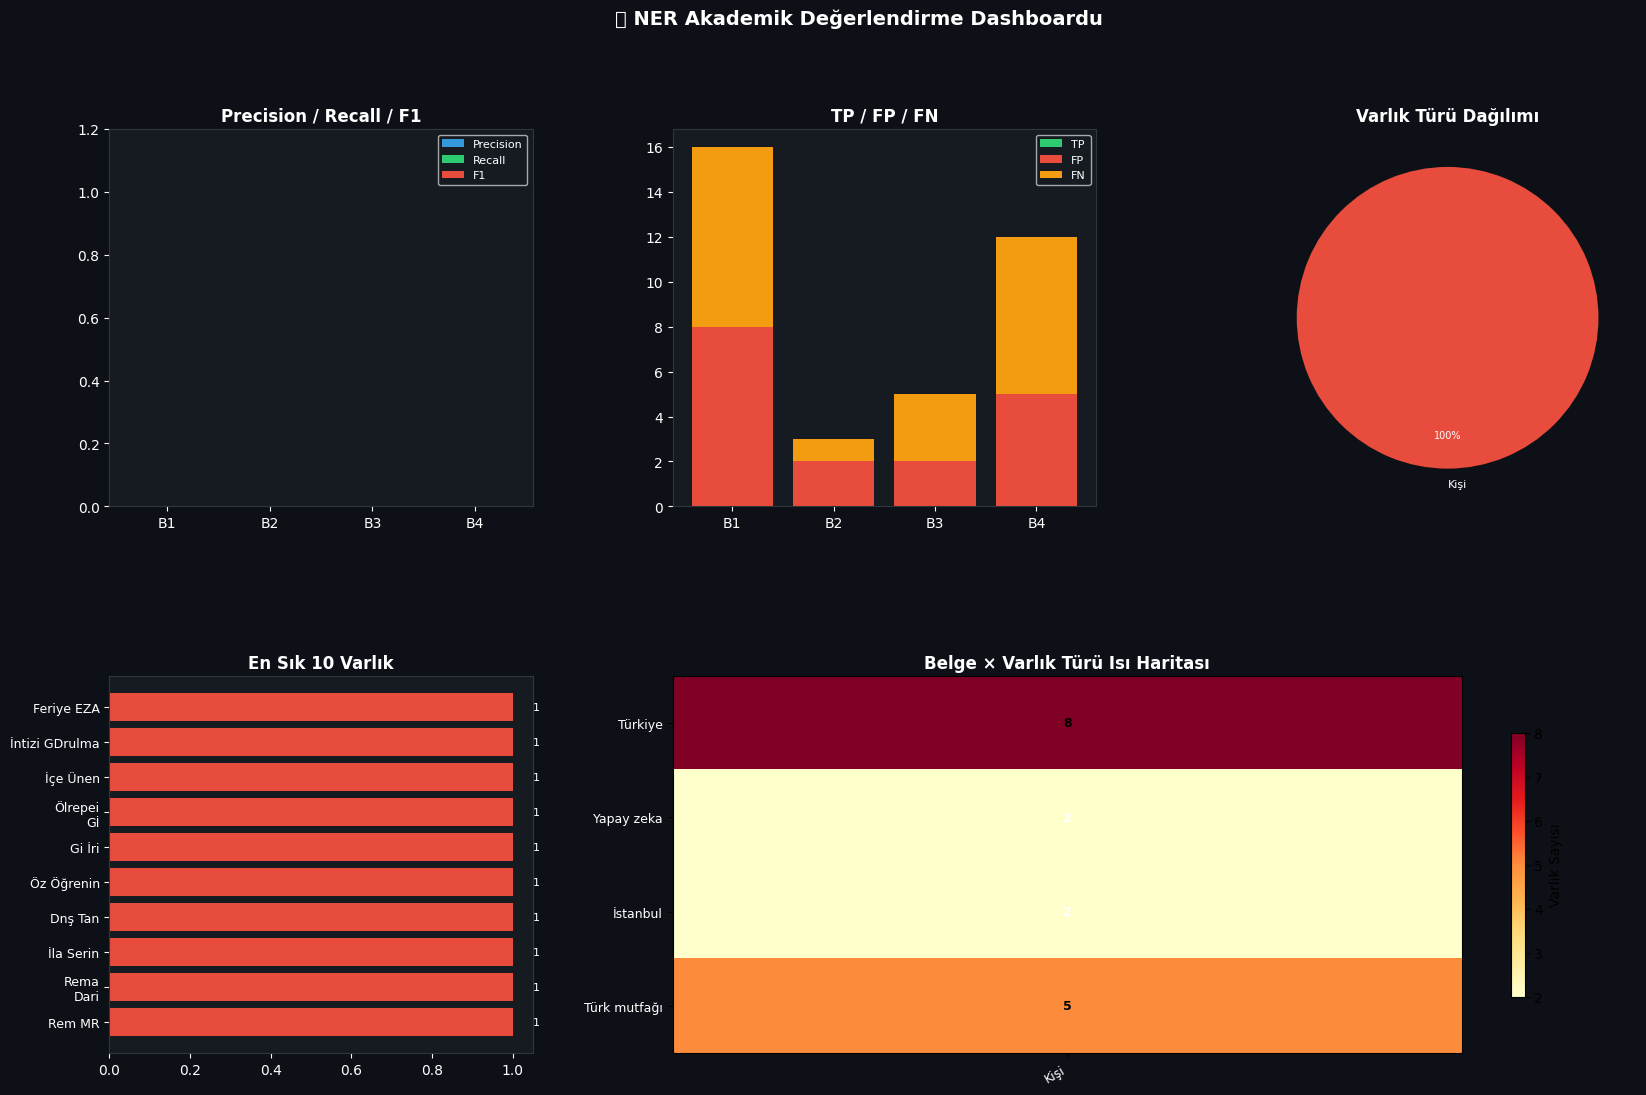

✅ NER dashboard kaydedildi


In [8]:
# ── BÖLÜM 2.3 — NER Görselleştirme Dashboardu ──────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns
import numpy as np
from collections import defaultdict, Counter

ENTITY_COLORS = {
    "PER":      "#e74c3c",
    "LOC":      "#2ecc71",
    "ORG":      "#3498db",
    "DATE":     "#f39c12",
    "MONEY":    "#9b59b6",
    "PERCENT":  "#1abc9c",
    "CARDINAL": "#e67e22",
    "MISC":     "#95a5a6",
}

fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor("#0d1117")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.33)

doc_names = [d["title"][:12] for d in DOCUMENTS]
metrics   = ner_eval["per_document"]
x         = np.arange(len(doc_names))
bw        = 0.25

# ── 1. Precision / Recall / F1 ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor("#161b22")
ax1.bar(x - bw, [m["precision"] for m in metrics], bw,
        label="Precision", color="#3498db", edgecolor="none")
ax1.bar(x,      [m["recall"]    for m in metrics], bw,
        label="Recall",    color="#2ecc71", edgecolor="none")
ax1.bar(x + bw, [m["f1"]        for m in metrics], bw,
        label="F1",        color="#e74c3c", edgecolor="none")
ax1.set_xticks(x)
ax1.set_xticklabels([f"B{i+1}" for i in range(len(doc_names))],
                    color="white", fontsize=10)
ax1.set_ylim(0, 1.2)
ax1.set_title("Precision / Recall / F1", color="white", fontweight="bold")
ax1.tick_params(colors="white")
ax1.spines[:].set_color("#30363d")
ax1.legend(facecolor="#161b22", labelcolor="white", fontsize=8)

# ── 2. TP / FP / FN ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor("#161b22")
tps = [m["tp"] for m in metrics]
fps = [m["fp"] for m in metrics]
fns = [m["fn"] for m in metrics]
ax2.bar(x, tps, color="#2ecc71", edgecolor="none", label="TP")
ax2.bar(x, fps, bottom=tps, color="#e74c3c", edgecolor="none", label="FP")
ax2.bar(x, fns, bottom=[t+f for t,f in zip(tps,fps)],
        color="#f39c12", edgecolor="none", label="FN")
ax2.set_xticks(x)
ax2.set_xticklabels([f"B{i+1}" for i in range(len(doc_names))],
                    color="white", fontsize=10)
ax2.set_title("TP / FP / FN", color="white", fontweight="bold")
ax2.tick_params(colors="white")
ax2.spines[:].set_color("#30363d")
ax2.legend(facecolor="#161b22", labelcolor="white", fontsize=8)

# ── 3. Varlık türü pasta grafiği ──────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor("#161b22")
all_by_label: Dict[str, int] = defaultdict(int)
for res in ner_results:
    for lbl, items in res["by_label"].items():
        all_by_label[lbl] += len(items)

if all_by_label:
    lbls   = list(all_by_label.keys())
    vals   = [all_by_label[l] for l in lbls]
    colors = [ENTITY_COLORS.get(l, "#7f8c8d") for l in lbls]
    lbl_tr = [ner.LABEL_TR.get(l, l) for l in lbls]
    wedges, texts, autos = ax3.pie(
        vals, labels=lbl_tr, colors=colors,
        autopct="%1.0f%%", startangle=90,
        textprops={"color": "white", "fontsize": 8},
        pctdistance=0.78,
    )
    for at in autos:
        at.set_fontsize(7)
ax3.set_title("Varlık Türü Dağılımı", color="white", fontweight="bold")

# ── 4. En sık 10 varlık ───────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor("#161b22")
all_flat = []
for res in ner_results:
    all_flat.extend([(e["text"], e["label"]) for e in res["entities"]])

top10 = Counter(e[0] for e in all_flat).most_common(10)
if top10:
    names_t, cnts = zip(*top10)
    ent_lbl  = {e[0]: e[1] for e in all_flat}
    bar_cls  = [ENTITY_COLORS.get(ent_lbl.get(n, "MISC"), "#7f8c8d") for n in names_t]
    bars     = ax4.barh(range(len(names_t)), cnts, color=bar_cls, edgecolor="none")
    ax4.set_yticks(range(len(names_t)))
    ax4.set_yticklabels(names_t, color="white", fontsize=9)
    ax4.set_title("En Sık 10 Varlık", color="white", fontweight="bold")
    ax4.tick_params(colors="white")
    ax4.spines[:].set_color("#30363d")
    for bar, c in zip(bars, cnts):
        ax4.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 str(c), va="center", color="white", fontsize=8)

# ── 5. Belge × Tür ısı haritası ──────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1:])
ax5.set_facecolor("#161b22")
all_lbls = sorted(all_by_label.keys())
matrix   = np.zeros((len(ner_results), len(all_lbls)))
for i, res in enumerate(ner_results):
    for j, lbl in enumerate(all_lbls):
        matrix[i, j] = len(res["by_label"].get(lbl, []))

lbl_tr_names = [ner.LABEL_TR.get(l, l) for l in all_lbls]
im = ax5.imshow(matrix, cmap="YlOrRd", aspect="auto")
ax5.set_xticks(range(len(all_lbls)))
ax5.set_xticklabels(lbl_tr_names, color="white", rotation=30,
                    ha="right", fontsize=9)
ax5.set_yticks(range(len(ner_results)))
ax5.set_yticklabels(doc_names, color="white", fontsize=9)
ax5.set_title("Belge × Varlık Türü Isı Haritası", color="white", fontweight="bold")
for i in range(len(ner_results)):
    for j in range(len(all_lbls)):
        if matrix[i, j] > 0:
            ax5.text(j, i, int(matrix[i, j]), ha="center", va="center",
                     color="black" if matrix[i, j] > matrix.max() * 0.5 else "white",
                     fontsize=9, fontweight="bold")
plt.colorbar(im, ax=ax5, shrink=0.7, label="Varlık Sayısı")

fig.suptitle("🏷️ NER Akademik Değerlendirme Dashboardu",
             color="white", fontsize=14, fontweight="bold")
plt.savefig(BASE / "output" / "ner_dashboard.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("✅ NER dashboard kaydedildi")

## 💬 BÖLÜM 3 — Duygu Analizi Modülü

Türkçe BERT modeli ile batch inference yapılır.

### Model
- `savasy/bert-base-turkish-sentiment-cased`
- CPU optimizasyonu: `torch.no_grad()`, batch boyutu 8
- Uzun metinler otomatik chunk'lara bölünür

### Akademik Metrikler
| Metrik | Açıklama |
|--------|----------|
| Accuracy | Doğru tahmin oranı |
| F1 Macro | Sınıf dengesiz veri için |
| F1 Weighted | Örnek sayısına göre ağırlıklı |
| Confusion Matrix | Sınıf bazında hata analizi |

### Model Detayları
| Özellik | Değer |
|---------|-------|
| Model | `savasy/bert-base-turkish-sentiment-cased` |
| Mimari | BERT (Bidirectional Encoder Representations from Transformers) |
| Çıktı | 3 sınıf: positive / negative / neutral |
| Donanım | CPU optimize (`torch.no_grad()` + batch inference, batch_size=8) |
| Max token | 512 (aşarsa otomatik chunking + ağırlıklı ortalama) |

### Akademik Metrikler
| Metrik | Açıklama |
|--------|----------|
| Accuracy | Tüm örneklerin yüzde kaçını doğru sınıflandırdı? |
| F1 Macro | Her sınıfa eşit ağırlık verir (dengesiz veri için tercih edilir) |
| F1 Weighted | Sınıf örnek sayısına göre ağırlıklandırılmış F1 |
| Confusion Matrix | Hangi sınıfların hangisiyle karıştırıldığını gösterir |

### 3.1 Değerlendirme Veri Seti

18 etiketli Türkçe cümle kullanılır: 6 pozitif, 6 negatif, 6 nötr. Bu cümleler gerçek dünya metinlerini temsil edecek şekilde seçilmiştir.


In [9]:
# ── BÖLÜM 3.1 — Değerlendirme Veri Seti ─────────────────────────────────────
# 18 etiketli Türkçe cümle: 6 pozitif, 6 negatif, 6 nötr

# Değerlendirme için etiketli Türkçe duygu dataseti
SENTIMENT_DATASET = [
    ("Türkiye ekonomisi güçlü büyüme gösteriyor, çok memnunum.", "positive"),
    ("TÜBİTAK Ar-Ge bütçesi artışı bilimi destekliyor, harika bir gelişme.", "positive"),
    ("Yeni üniversiteler eğitime büyük katkı sağlıyor.", "positive"),
    ("Sağlık turizmi gelir artışı ekonomiye olumlu katkı sağlıyor.", "positive"),
    ("Yapay zeka alanındaki gelişmeler insanlık için umut verici.", "positive"),
    ("Bu proje başarıyla tamamlandı, takım mükemmel iş çıkardı.", "positive"),
    ("Enflasyon nedeniyle yaşam maliyeti giderek artıyor, endişe verici.", "negative"),
    ("Trafik sorunu çözülemiyor, her gün saatler kaybediliyor.", "negative"),
    ("Doğal afetler büyük yıkıma neden oluyor, çok üzücü.", "negative"),
    ("Eğitim kalitesindeki düşüş gençlerin geleceğini tehdit ediyor.", "negative"),
    ("İşsizlik oranları kabul edilemez seviyelere ulaştı.", "negative"),
    ("Bu politika tamamen başarısız, hiçbir işe yaramadı.", "negative"),
    ("Hava durumu yarın bulutlu olacak.", "neutral"),
    ("Toplantı saat 14:00'te başlayacak.", "neutral"),
    ("Rapor 50 sayfadan oluşmaktadır.", "neutral"),
    ("İstanbul nüfusu 15 milyonu aşmaktadır.", "neutral"),
    ("Proje 24 ay içinde tamamlanacaktır.", "neutral"),
    ("Bütçe 3,2 milyar TL olarak belirlenmiştir.", "neutral"),
]

print(f"✅ Sentiment dataset hazır | {len(SENTIMENT_DATASET)} örnek")
pos = sum(1 for _, l in SENTIMENT_DATASET if l == "positive")
neg = sum(1 for _, l in SENTIMENT_DATASET if l == "negative")
neu = sum(1 for _, l in SENTIMENT_DATASET if l == "neutral")
print(f"   Pozitif: {pos} | Negatif: {neg} | Nötr: {neu}")

✅ Sentiment dataset hazır | 18 örnek
   Pozitif: 6 | Negatif: 6 | Nötr: 6


### 3.2 SentimentModule Sınıfı

`SentimentModule` şu özellikleri içerir:
- **Batch inference:** `BATCH_SIZE=8` ile bellek verimli gruplu işlem
- **Chunking:** 512 token limitini aşan metinler cümle sınırlarından kesilir;   parçalar uzunlukla orantılı ağırlıklı ortalama ile birleştirilir
- **return_all_scores:** tüm sınıf olasılıkları alınır, en yüksek skor döner
- **Label normalization:** `LABEL_0/1/2` gibi ham etiketler `negative/positive/neutral`'a eşlenir


In [10]:
# ── BÖLÜM 3.2 — SentimentModule Sınıfı ─────────────────────────────────────
# BERT tabanlı Türkçe duygu analizi: batch inference, chunking, sklearn metrikleri

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline as hf_pipeline,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)
import re, gc
import numpy as np
from collections import defaultdict
from typing import Dict, Any, List, Tuple, Optional

class SentimentModule:
    """
    Türkçe metinler için BERT tabanlı duygu analizi modülü.

    Özellikler:
        - Batch inference: bellek verimli gruplu işlem
        - Chunking: 512 token limitini aşan metinler otomatik bölünür
        - return_all_scores: tüm sınıf olasılıkları alınır
        - Sklearn: Precision / Recall / F1 / Confusion Matrix
    """

    MODEL_NAME = "savasy/bert-base-turkish-sentiment-cased"
    BATCH_SIZE  = 8
    MAX_LENGTH  = 512

    LABEL_META: Dict[str, Dict] = {
        "positive": {"tr": "Pozitif", "emoji": "😊", "color": "#2ecc71"},
        "negative": {"tr": "Negatif", "emoji": "😞", "color": "#e74c3c"},
        "neutral":  {"tr": "Nötr",    "emoji": "😐", "color": "#95a5a6"},
        "LABEL_0":  {"tr": "Negatif", "emoji": "😞", "color": "#e74c3c"},
        "LABEL_1":  {"tr": "Pozitif", "emoji": "😊", "color": "#2ecc71"},
        "LABEL_2":  {"tr": "Nötr",    "emoji": "😐", "color": "#95a5a6"},
    }

    def __init__(self) -> None:
        self.logger = make_logger("Sentiment")
        self.logger.info(f"Model yükleniyor: {self.MODEL_NAME}")

        self.tokenizer = AutoTokenizer.from_pretrained(self.MODEL_NAME)
        self.model     = AutoModelForSequenceClassification.from_pretrained(
            self.MODEL_NAME
        )
        self.model.eval()

        self.clf = hf_pipeline(
            "sentiment-analysis",
            model=self.model,
            tokenizer=self.tokenizer,
            device=-1,
            return_all_scores=True,
            truncation=True,
            max_length=self.MAX_LENGTH,
        )
        self.logger.info("✅ Duygu analizi modeli hazır")

    def _chunk_text(self, text: str, max_tokens: int = 400) -> List[str]:
        sentences   = re.split(r"(?<=[.!?])\s+", text.strip())
        chunks: List[str] = []
        current     = ""
        current_len = 0

        for sent in sentences:
            sent_len = len(self.tokenizer.encode(sent, add_special_tokens=False))
            if current_len + sent_len > max_tokens and current:
                chunks.append(current)
                current     = sent
                current_len = sent_len
            else:
                current     = (current + " " + sent).strip() if current else sent
                current_len += sent_len

        if current:
            chunks.append(current)

        return chunks if chunks else [text[:800]]

    def _normalize_label(self, raw: str) -> str:
        raw = raw.lower().strip()
        if raw in ("positive", "label_1"):
            return "positive"
        if raw in ("negative", "label_0"):
            return "negative"
        if raw in ("neutral",  "label_2"):
            return "neutral"
        return "neutral"

    def analyze_single(self, text: str) -> Dict[str, Any]:
        if not text.strip():
            return {
                "label": "neutral", "label_tr": "Nötr",
                "emoji": "😐", "color": "#95a5a6",
                "score": 0.0, "all_scores": {}, "chunk_count": 0,
            }

        chunks        = self._chunk_text(text)
        chunk_results = []

        for chunk in chunks:
            if not chunk.strip():
                continue
            try:
                # return_all_scores=True → [[{label, score}, ...]]
                raw = self.clf(chunk)
                out = raw[0] if isinstance(raw[0], list) else raw
                scores = {item["label"]: item["score"] for item in out}
                best   = max(out, key=lambda x: x["score"])
                chunk_results.append({
                    "label":      best["label"],
                    "score":      best["score"],
                    "all_scores": scores,
                    "length":     len(chunk),
                })
            except Exception as e:
                self.logger.warning(f"Chunk hatası: {e}")

        if not chunk_results:
            return {
                "label": "neutral", "label_tr": "Nötr",
                "emoji": "😐", "color": "#95a5a6",
                "score": 0.0, "all_scores": {}, "chunk_count": 0,
            }

        # Ağırlıklı ortalama
        total_w        = sum(c["length"] for c in chunk_results)
        agg: Dict[str, float] = defaultdict(float)
        for c in chunk_results:
            w = c["length"] / total_w
            for lbl, sc in c["all_scores"].items():
                agg[lbl] += sc * w

        best_lbl = max(agg, key=agg.get)
        best_sc  = agg[best_lbl]
        norm_lbl = self._normalize_label(best_lbl)
        meta     = self.LABEL_META.get(norm_lbl, self.LABEL_META["neutral"])

        return {
            "label":       norm_lbl,
            "label_tr":    meta["tr"],
            "emoji":       meta["emoji"],
            "color":       meta["color"],
            "score":       round(best_sc, 4),
            "all_scores":  {self._normalize_label(k): round(v, 4)
                            for k, v in agg.items()},
            "chunk_count": len(chunk_results),
        }

    def analyze_batch(self, texts: List[str]) -> List[Dict[str, Any]]:
        results = []
        for i in range(0, len(texts), self.BATCH_SIZE):
            batch = texts[i: i + self.BATCH_SIZE]
            self.logger.info(
                f"Batch [{i+1}–{min(i+self.BATCH_SIZE, len(texts))}/{len(texts)}]"
            )
            for text in batch:
                results.append(self.analyze_single(text))
            gc.collect()
        return results

    def evaluate(
        self,
        y_true: List[str],
        y_pred: List[str],
    ) -> Dict[str, Any]:
        labels = ["positive", "negative", "neutral"]
        report = classification_report(
            y_true, y_pred,
            labels=labels,
            target_names=["Pozitif", "Negatif", "Nötr"],
            output_dict=True,
            zero_division=0,
        )
        cm   = confusion_matrix(y_true, y_pred, labels=labels)
        f1_m = f1_score(y_true, y_pred, labels=labels,
                        average="macro",    zero_division=0)
        f1_w = f1_score(y_true, y_pred, labels=labels,
                        average="weighted", zero_division=0)
        acc  = sum(p == t for p, t in zip(y_pred, y_true)) / len(y_true)

        return {
            "report":      report,
            "cm":          cm,
            "f1_macro":    round(float(f1_m), 4),
            "f1_weighted": round(float(f1_w), 4),
            "accuracy":    round(acc, 4),
        }

print("✅ SentimentModule tanımlandı")

✅ SentimentModule tanımlandı


### 3.3 Duygu Analizi Çalıştırma

İki ayrı analiz gerçekleştirilir:
1. **OCR belgeleri** — Wikipedia'dan çekilen belgeler analiz edilir
2. **Değerlendirme dataseti** — 18 etiketli cümle üzerinden Accuracy, F1 Macro, F1 Weighted hesaplanır


In [11]:
# ── BÖLÜM 3.3 — Duygu Analizi Çalıştırma ────────────────────────────────────

with measure("Duygu Analizi"):
    sentiment_module = SentimentModule()

    # OCR belgelerini analiz et
    ocr_sentiments = sentiment_module.analyze_batch(ocr_texts)

    # Değerlendirme dataseti
    dataset_texts  = [row[0] for row in SENTIMENT_DATASET]
    dataset_labels = [row[1] for row in SENTIMENT_DATASET]
    dataset_preds  = sentiment_module.analyze_batch(dataset_texts)
    pred_labels    = [p["label"] for p in dataset_preds]
    eval_result    = sentiment_module.evaluate(dataset_labels, pred_labels)

print("\n💬 OCR Belgesi Duygu Sonuçları")
print("─" * 50)
for res, doc in zip(ocr_sentiments, DOCUMENTS):
    print(f"  {doc['title']:<25} {res['emoji']} {res['label_tr']:<10} "
          f"Skor: {res['score']*100:.1f}%  Chunk: {res['chunk_count']}")

print(f"\n📊 Değerlendirme (n={len(SENTIMENT_DATASET)} örnek)")
print(f"  Accuracy     : {eval_result['accuracy']*100:.1f}%")
print(f"  F1 Macro     : {eval_result['f1_macro']:.3f}")
print(f"  F1 Weighted  : {eval_result['f1_weighted']:.3f}")

08:32:28 | INFO     | Pipeline           | ▶ [Duygu Analizi] başlıyor | RAM: 1120/12976 MB (8.6%)
INFO:Pipeline:▶ [Duygu Analizi] başlıyor | RAM: 1120/12976 MB (8.6%)
08:32:28 | INFO     | Sentiment          | Model yükleniyor: savasy/bert-base-turkish-sentiment-cased
INFO:Sentiment:Model yükleniyor: savasy/bert-base-turkish-sentiment-cased
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:104: UserWarning: `return_all_scores` is now deprecat


💬 OCR Belgesi Duygu Sonuçları
──────────────────────────────────────────────────
  Türkiye                   😊 Pozitif    Skor: 51.7%  Chunk: 1
  Yapay zeka                😞 Negatif    Skor: 98.3%  Chunk: 1
  İstanbul                  😊 Pozitif    Skor: 87.7%  Chunk: 1
  Türk mutfağı              😞 Negatif    Skor: 71.0%  Chunk: 1

📊 Değerlendirme (n=18 örnek)
  Accuracy     : 50.0%
  F1 Macro     : 0.389
  F1 Weighted  : 0.389


### 3.4 Duygu Analizi Görselleştirme Dashboardu

5 panelden oluşan bir dashboard üretilir:

1. **Confusion Matrix** — sınıflandırma hataları heatmap olarak
2. **Sınıf bazında Precision / Recall / F1** — Pozitif, Negatif, Nötr karşılaştırması
3. **OCR belgeleri duygu dağılımı** — yığılmış bar; her bar pozitif/negatif/nötr olasılıklarını gösterir
4. **Gerçek vs Tahmin dağılımı** — öngörülen ve gerçek etiket sayıları yan yana
5. **Genel performans özeti** — Accuracy, F1 Macro/Weighted ve sınıf bazında Precision/Recall metin paneli


/tmp/ipykernel_32421/1365389406.py:131: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) DejaVu Sans.
  plt.savefig(BASE / "output" / "sentiment_dashboard.png",
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


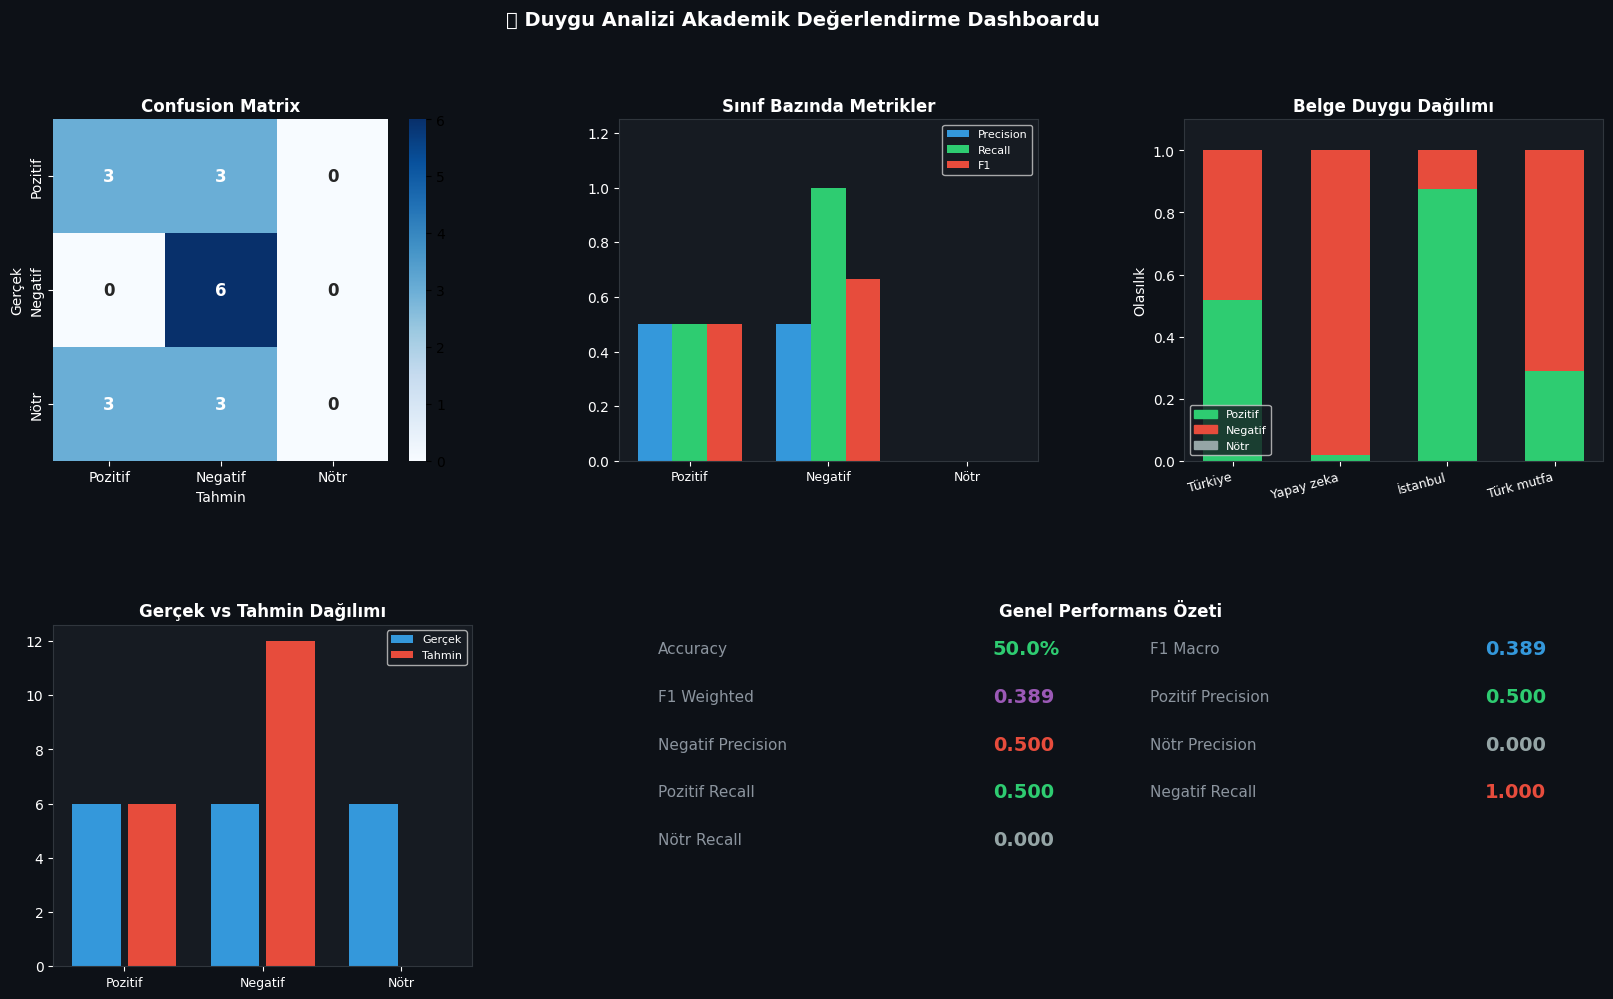

✅ Duygu analizi dashboardu kaydedildi


In [12]:
# ── BÖLÜM 3.4 — Duygu Analizi Görselleştirme Dashboardu ────────────────────

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch

fig = plt.figure(figsize=(20, 11))
fig.patch.set_facecolor("#0d1117")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.35)

# ── 1. Confusion Matrix ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor("#161b22")
sns.heatmap(
    eval_result["cm"],
    annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pozitif", "Negatif", "Nötr"],
    yticklabels=["Pozitif", "Negatif", "Nötr"],
    ax=ax1, annot_kws={"size": 12, "fontweight": "bold"},
)
ax1.set_xlabel("Tahmin", color="white", fontsize=10)
ax1.set_ylabel("Gerçek",  color="white", fontsize=10)
ax1.set_title("Confusion Matrix", color="white", fontweight="bold")
ax1.tick_params(colors="white")

# ── 2. Sınıf bazında Precision / Recall / F1 ─────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor("#161b22")
rpt        = eval_result["report"]
cls_labels = ["Pozitif", "Negatif", "Nötr"]
xpos       = np.arange(len(cls_labels))
bw         = 0.25
ax2.bar(xpos - bw, [rpt[c]["precision"] for c in cls_labels], bw,
        label="Precision", color="#3498db", edgecolor="none")
ax2.bar(xpos,      [rpt[c]["recall"]    for c in cls_labels], bw,
        label="Recall",    color="#2ecc71", edgecolor="none")
ax2.bar(xpos + bw, [rpt[c]["f1-score"]  for c in cls_labels], bw,
        label="F1",        color="#e74c3c", edgecolor="none")
ax2.set_xticks(xpos)
ax2.set_xticklabels(cls_labels, color="white", fontsize=9)
ax2.set_ylim(0, 1.25)
ax2.set_title("Sınıf Bazında Metrikler", color="white", fontweight="bold")
ax2.tick_params(colors="white")
ax2.spines[:].set_color("#30363d")
ax2.legend(facecolor="#161b22", labelcolor="white", fontsize=8)

# ── 3. OCR belgeleri duygu dağılımı ──────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor("#161b22")
for i, (res, doc) in enumerate(zip(ocr_sentiments, DOCUMENTS)):
    sc_dict   = res["all_scores"]
    cls_order = ["positive", "negative", "neutral"]
    scs       = [sc_dict.get(c, 0.0) for c in cls_order]
    colors_b  = ["#2ecc71", "#e74c3c", "#95a5a6"]
    bottom    = 0
    for sc, clr in zip(scs, colors_b):
        ax3.bar(i, sc, bottom=bottom, color=clr, edgecolor="none", width=0.55)
        bottom += sc
ax3.set_xticks(range(len(DOCUMENTS)))
ax3.set_xticklabels([d["title"][:10] for d in DOCUMENTS],
                    color="white", fontsize=9, rotation=15, ha="right")
ax3.set_ylim(0, 1.1)
ax3.set_ylabel("Olasılık", color="white")
ax3.set_title("Belge Duygu Dağılımı", color="white", fontweight="bold")
ax3.tick_params(colors="white")
ax3.spines[:].set_color("#30363d")
ax3.legend(handles=[
    Patch(color="#2ecc71", label="Pozitif"),
    Patch(color="#e74c3c", label="Negatif"),
    Patch(color="#95a5a6", label="Nötr"),
], facecolor="#161b22", labelcolor="white", fontsize=8)

# ── 4. Gerçek vs Tahmin dağılımı ──────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor("#161b22")
true_counts = {"positive": 0, "negative": 0, "neutral": 0}
pred_counts = {"positive": 0, "negative": 0, "neutral": 0}
for t, p in zip(dataset_labels, pred_labels):
    true_counts[t] += 1
    pred_counts[p] += 1
xc = np.arange(3)
ax4.bar(xc - 0.2,
        [true_counts[c] for c in ["positive", "negative", "neutral"]], 0.35,
        label="Gerçek", color="#3498db", edgecolor="none")
ax4.bar(xc + 0.2,
        [pred_counts[c] for c in ["positive", "negative", "neutral"]], 0.35,
        label="Tahmin", color="#e74c3c", edgecolor="none")
ax4.set_xticks(xc)
ax4.set_xticklabels(["Pozitif", "Negatif", "Nötr"], color="white", fontsize=9)
ax4.set_title("Gerçek vs Tahmin Dağılımı", color="white", fontweight="bold")
ax4.tick_params(colors="white")
ax4.spines[:].set_color("#30363d")
ax4.legend(facecolor="#161b22", labelcolor="white", fontsize=8)

# ── 5. Genel metrik özet ──────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1:])
ax5.set_facecolor("#161b22")
ax5.axis("off")
summary = [
    ("Accuracy",          f"{eval_result['accuracy']*100:.1f}%",  "#2ecc71"),
    ("F1 Macro",          f"{eval_result['f1_macro']:.3f}",        "#3498db"),
    ("F1 Weighted",       f"{eval_result['f1_weighted']:.3f}",     "#9b59b6"),
    ("Pozitif Precision", f"{rpt['Pozitif']['precision']:.3f}",    "#2ecc71"),
    ("Negatif Precision", f"{rpt['Negatif']['precision']:.3f}",    "#e74c3c"),
    ("Nötr Precision",    f"{rpt['Nötr']['precision']:.3f}",       "#95a5a6"),
    ("Pozitif Recall",    f"{rpt['Pozitif']['recall']:.3f}",       "#2ecc71"),
    ("Negatif Recall",    f"{rpt['Negatif']['recall']:.3f}",       "#e74c3c"),
    ("Nötr Recall",       f"{rpt['Nötr']['recall']:.3f}",          "#95a5a6"),
]
cols = [(0.04, 0.38), (0.54, 0.88)]
rows = [(summary[i], summary[i+1] if i+1 < len(summary) else None)
        for i in range(0, len(summary), 2)]

for row_i, row in enumerate(rows):
    y = 0.93 - row_i * 0.14
    for col_i, item in enumerate(row):
        if item is None:
            continue
        name, value, color = item
        ax5.text(cols[col_i][0], y, name,  transform=ax5.transAxes,
                 color="#8b949e", fontsize=11, va="center")
        ax5.text(cols[col_i][1], y, value, transform=ax5.transAxes,
                 color=color, fontsize=14, fontweight="bold", va="center")

ax5.set_title("Genel Performans Özeti", color="white", fontweight="bold")

fig.suptitle("💬 Duygu Analizi Akademik Değerlendirme Dashboardu",
             color="white", fontsize=14, fontweight="bold")
plt.savefig(BASE / "output" / "sentiment_dashboard.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("✅ Duygu analizi dashboardu kaydedildi")

## 🔍 BÖLÜM 4 — RAG Modülü

### Mimari
| Bileşen | Detay |
|---------|-------|
| Embedding | `paraphrase-multilingual-MiniLM-L12-v2` — 50 dil, 384 boyut |
| Chunking | RecursiveChunker — paragraf → cümle → overlap |
| Retrieval | FAISS IndexFlatIP — normalize edilmiş kosinüs benzerliği |
| Generation | Extractive — retrieved chunk'lardan cevap üretme |
| Değerlendirme | MRR + Hit@K |
| Arayüz | Gradio — koyu tema |

RAG (Retrieval-Augmented Generation), bilgi tabanından ilgili parçaları bulup bunlara dayalı cevap üretir. Bu bölümde gerçek embedding tabanlı bir RAG sistemi oluşturulur.

### 4.1 RecursiveChunker & RagModule Sınıfları

**RecursiveChunker:** Uzun metinleri paragraf → cümle → overlap hiyerarşisinde böler. `overlap` parametresi, parçalar arası bağlam kaybolmamasını sağlar.

**RagModule pipeline'ı:**
1. Belgeler RecursiveChunker ile chunk'lara bölünür
2. Her chunk SentenceTransformer ile 384-boyutlu vektöre dönüştürülür
3. FAISS IndexFlatIP (kosinüs benzerliği için normalize edilmiş iç çarpım) indeksi oluşturulur
4. Sorgu embedding'i hesaplanır, en yakın k chunk getirilir
5. Extractive generation: en yüksek puanlı cümleler cevap olarak döner
6. MRR (Mean Reciprocal Rank) + Hit@K ile retrieval kalitesi ölçülür




In [13]:
# ── BÖLÜM 4.1 — RecursiveChunker & RagModule Sınıfları ─────────────────────
# FAISS vektör indeksi + kosinüs benzerliği + MRR/Hit@K değerlendirmesi

import faiss
import numpy as np
import gc
import re
from sentence_transformers import SentenceTransformer
from typing import Dict, Any, List, Optional, Tuple


class RecursiveChunker:
    def __init__(self, max_chars: int = 400, overlap: int = 60) -> None:
        self.max_chars = max_chars
        self.overlap = overlap

    def split(self, text: str) -> List[str]:
        paras = [p.strip() for p in re.split(r"\n\n+", text) if p.strip()]
        chunks = []
        current = ""

        for para in paras:
            if len(current) + len(para) <= self.max_chars:
                current = (current + " " + para).strip() if current else para
            else:
                if current:
                    chunks.append(current)

                if len(para) > self.max_chars:
                    sents = re.split(r"(?<=[.!?])\s+", para)
                    sub = ""

                    for s in sents:
                        if len(sub) + len(s) <= self.max_chars:
                            sub = (sub + " " + s).strip() if sub else s
                        else:
                            if sub:
                                chunks.append(sub)
                            sub = s

                    if sub:
                        chunks.append(sub)

                    current = ""
                else:
                    current = para

        if current:
            chunks.append(current)

        if self.overlap > 0 and len(chunks) > 1:
            overlapped = [chunks[0]]

            for i in range(1, len(chunks)):
                tail = chunks[i - 1][-self.overlap:]
                overlapped.append((tail + " " + chunks[i]).strip())

            return overlapped

        return chunks if chunks else [text]


class RagModule:
    EMBED_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"

    def __init__(
        self,
        documents: List[str],
        max_chars: int = 400,
        overlap: int = 60,
        top_k: int = 5,
    ) -> None:

        self.logger = make_logger("RAG")
        self.top_k = top_k
        self.chunker = RecursiveChunker(
            max_chars=max_chars,
            overlap=overlap
        )

        self.logger.info(
            f"Embedding modeli yükleniyor: {self.EMBED_MODEL}"
        )

        self.encoder = SentenceTransformer(self.EMBED_MODEL)

        self.logger.info("✅ SentenceTransformer hazır")

        self._build(documents)

    def _build(self, documents: List[str]) -> None:
        self.chunks: List[str] = []
        self.chunk_doc: List[int] = []

        for doc_i, doc in enumerate(documents):
            for part in self.chunker.split(doc):
                if part.strip():
                    self.chunks.append(part)
                    self.chunk_doc.append(doc_i)

        self.logger.info(
            f"Chunking: {len(documents)} belge → "
            f"{len(self.chunks)} chunk"
        )

        embeddings = self.encoder.encode(
            self.chunks,
            batch_size=32,
            show_progress_bar=True,
            convert_to_numpy=True,
            normalize_embeddings=True,
        ).astype(np.float32)

        dim = embeddings.shape[1]

        self.index = faiss.IndexFlatIP(dim)
        self.index.add(embeddings)

        self.logger.info(
            f"✅ FAISS hazır | "
            f"{self.index.ntotal} vektör | dim={dim}"
        )

        gc.collect()

    def retrieve(
        self,
        query: str,
        top_k: Optional[int] = None
    ) -> List[Dict[str, Any]]:

        k = min(top_k or self.top_k, len(self.chunks))

        q_vec = self.encoder.encode(
            [query],
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=False,
        ).astype(np.float32)

        scores, indices = self.index.search(q_vec, k)

        results = []

        for sc, idx in zip(scores[0], indices[0]):
            if idx < 0:
                continue

            results.append({
                "chunk": self.chunks[idx],
                "score": round(float(sc), 4),
                "doc_id": self.chunk_doc[idx],
                "preview": self.chunks[idx][:180] + "...",
            })

        return results

    def generate(
        self,
        query: str,
        top_k: Optional[int] = None
    ) -> Dict[str, Any]:

        sources = self.retrieve(query, top_k)

        if not sources:
            return {
                "answer": "Uygun bilgi bulunamadı.",
                "sources": [],
                "confidence": 0.0,
                "context": "",
                "query": query,
            }

        stop_words = {
            "ve", "ile", "bir", "bu", "da", "de", "mi", "mu",
            "ne", "ki", "için", "hakkında", "nedir", "nasıl",
            "hangi", "kaç", "nerede", "kim", "ne zaman",
        }

        query_words = {
            w.lower()
            for w in re.sub(r"[?!.,;]", "", query).split()
            if w.lower() not in stop_words and len(w) > 2
        }

        scored: List[Tuple[float, str]] = []

        for src in sources[:3]:
            for sent in re.split(r"(?<=[.!?])\s+", src["chunk"]):

                if len(sent) < 20:
                    continue

                overlap = sum(
                    1
                    for w in sent.lower().split()
                    if w in query_words
                )

                scored.append((
                    src["score"] * (1 + 0.4 * overlap),
                    sent
                ))

        scored.sort(key=lambda x: x[0], reverse=True)

        best = [s for _, s in scored[:3]]

        if not best:
            best = re.split(
                r"(?<=[.!?])\s+",
                sources[0]["chunk"]
            )[:2]

        answer = " ".join(best).strip()

        context = "\n\n".join(
            f"[Kaynak {i + 1} | Skor: {s['score']:.4f}]\n{s['chunk']}"
            for i, s in enumerate(sources)
        )

        return {
            "answer": answer,
            "sources": sources,
            "confidence": sources[0]["score"],
            "context": context,
            "query": query,
        }

    def evaluate_retrieval(
        self,
        queries: List[str],
        relevants: List[List[str]],
        k: int = 5,
    ) -> Dict[str, float]:

        rr_sum = 0.0
        hit = 0

        for query, kws in zip(queries, relevants):

            results = self.retrieve(query, top_k=k)

            for rank, res in enumerate(results, 1):

                if any(
                    kw.lower() in res["chunk"].lower()
                    for kw in kws
                ):
                    rr_sum += 1 / rank
                    hit += 1
                    break

        n = len(queries)

        return {
            "mrr": round(rr_sum / n if n else 0.0, 4),
            "hit_at_k": round(hit / n if n else 0.0, 4),
            "k": k,
        }


print("✅ RecursiveChunker ve RagModule tanımlandı")

✅ RecursiveChunker ve RagModule tanımlandı


### 4.2 Bilgi Tabanı & RAG Başlatma

Beş adet Türkçe bilgi belgesi tanımlanır: RAG/FAISS açıklaması, SentenceTransformer/chunking, Transformer/BERT/overfitting, İstanbul/üniversiteler, Karadeniz/Akdeniz şehirleri. Bu belgeler OCR'dan gelen temiz metinlerle birleştirilerek `FULL_KB` bilgi tabanı oluşturulur. Ardından `RagModule` başlatılır ve FAISS indeksi kurulur.


In [14]:
# ── BÖLÜM 4.2 — Bilgi Tabanı & RAG Başlatma ────────────────────────────────

KNOWLEDGE_BASE = [
    """
    RAG, Retrieval-Augmented Generation kelimelerinin kısaltmasıdır.
    Bilgi tabanından ilgili parçaları getirip cevap üretmeye yarayan
    bir yapay zeka mimarisidir. FAISS, Facebook AI tarafından
    geliştirilen vektör benzerlik arama kütüphanesidir.
    IndexFlatIP kosinüs benzerliği ile çalışır ve normalize edilmiş
    vektörlerde en iyi performansı verir.
    """,

    """
    SentenceTransformer, cümleleri anlamsal olarak temsil eden
    embedding vektörleri üretir.
    paraphrase-multilingual-MiniLM-L12-v2 modeli 50'den fazla dili
    destekler ve 384 boyutlu vektörler üretir.

    Chunking işlemi uzun metinleri daha küçük parçalara böler.
    Overlap kullanımı cümle bağlamının kaybolmamasını sağlar.
    """,

    """
    Transformer mimarisi, dikkat mekanizmasını
    (attention mechanism) temel alır.

    BERT modeli çift yönlü transformer kullanarak
    metin anlama görevlerinde kullanılır.

    Overfitting, modelin eğitim verisini ezberleyip
    yeni verilere genelleme yapamaması durumudur.

    Etiketli veri, makine öğreniminde modelin öğrenmesi için
    doğru cevapların verildiği veridir.
    """,

    """
    İstanbul, Türkiye'nin en kalabalık şehridir ve
    iki kıtaya yayılmaktadır.

    Boğaziçi Üniversitesi, Sabancı Üniversitesi ve İTÜ,
    İstanbul'da yer alan önde gelen yükseköğretim kurumlarıdır.

    Ankara, Türkiye'nin başkenti olup ODTÜ ve
    Hacettepe Üniversitesi gibi köklü kurumları barındırmaktadır.

    Gaziantep, güneydoğu Türkiye'nin ekonomik ve kültürel
    merkezi konumundadır.
    """,

    """
    Antalya, Akdeniz kıyısında yer alan ve turizm açısından
    Türkiye'nin en önemli şehirlerinden biridir.

    Trabzon, Karadeniz kıyısında yer alır.

    Samsun da Karadeniz'in önemli liman şehirlerindendir.

    Türkiye'nin güneydoğusunda Diyarbakır,
    tarihi surlarıyla UNESCO Dünya Mirası listesindedir.

    İzmir, Ege kıyısındaki Türkiye'nin üçüncü büyük şehridir.
    """
]

FULL_KB = KNOWLEDGE_BASE + [
    t for t in ocr_texts
    if len(t) > 50
]

print(f"✅ Bilgi tabanı hazır | {len(FULL_KB)} belge")

print("\n🔧 RAG modülü başlatılıyor...")

rag = RagModule(
    documents=FULL_KB,
    max_chars=400,
    overlap=60,
    top_k=5,
)

print("\n✅ RAG hazır!")
print(f" Belge sayısı : {len(FULL_KB)}")
print(f" Chunk sayısı : {len(rag.chunks)}")
print(f" FAISS vektör : {rag.index.ntotal}")

08:33:44 | INFO     | RAG                | Embedding modeli yükleniyor: paraphrase-multilingual-MiniLM-L12-v2
INFO:RAG:Embedding modeli yükleniyor: paraphrase-multilingual-MiniLM-L12-v2


✅ Bilgi tabanı hazır | 9 belge

🔧 RAG modülü başlatılıyor...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

08:33:54 | INFO     | RAG                | ✅ SentenceTransformer hazır
INFO:RAG:✅ SentenceTransformer hazır
08:33:54 | INFO     | RAG                | Chunking: 9 belge → 9 chunk
INFO:RAG:Chunking: 9 belge → 9 chunk


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

08:33:55 | INFO     | RAG                | ✅ FAISS hazır | 9 vektör | dim=384
INFO:RAG:✅ FAISS hazır | 9 vektör | dim=384



✅ RAG hazır!
 Belge sayısı : 9
 Chunk sayısı : 9
 FAISS vektör : 9


### 4.3 Benchmark Değerlendirmesi & Demo Sorgular

**BENCHMARK_QA:** 60 sorudan oluşan bir benchmark seti. Her soru için beklenen anahtar kelimeler tanımlanmıştır. Retrieval kalitesi MRR ve Hit@5 ile ölçülür:
- **MRR** (Mean Reciprocal Rank): İlk doğru sonucun sırasının tersinin ortalaması
- **Hit@K**: En az bir doğru sonucun ilk K içinde bulunma oranı

**Demo sorgular:** 5 gerçek soru üzerinde `rag.generate()` çalıştırılır ve cevap + güven skoru gösterilir.


In [15]:
# ── BÖLÜM 4.3 — Benchmark & Demo Sorgular ───────────────────────────────────

BENCHMARK_QA = [
    ("Türkiye'nin yüzölçümü ne kadardır?", ["783.000"]),
    ("Türkiye'nin başkenti neresidir?", ["Ankara"]),
    ("Türkiye kaç ilden oluşmaktadır?", ["81"]),
    ("Türkiye'nin en kalabalık şehri hangisidir?", ["İstanbul"]),
    ("İstanbul'un nüfusu ne kadardır?", ["15 milyon"]),
    ("Türkiye 2023 yılında kaç turist ağırlamıştır?", ["50 milyon"]),
    ("Türkiye hangi kıtalara yayılmaktadır?", ["Asya", "Avrupa"]),
    ("Türkiye hangi denizlere kıyısı vardır?", ["Karadeniz", "Ege", "Akdeniz"]),
    ("TÜBİTAK'ın 2024 Ar-Ge bütçesi nedir?", ["3,2 milyar"]),
    ("Türkiye'de hangi savunma sanayi şirketleri öne çıkmaktadır?", ["ASELSAN", "ROKETSAN", "BAYKAR"]),
    ("Türkiye hangi uluslararası ekonomik gruba üyedir?", ["G20"]),
    ("Türkiye'de ihracatta öne çıkan sektörler nelerdir?", ["otomotiv", "tekstil", "gıda"]),
    ("Türk ekonomisinin temel sektörleri nelerdir?", ["sanayi", "tarım", "hizmet"]),
    ("Türkiye'deki üniversite sayısı ne kadardır?", ["200"]),
    ("Türkiye'deki toplam üniversite öğrencisi sayısı nedir?", ["8,5 milyon"]),
    ("2023 YKS'ye kaç aday katılmıştır?", ["2.847.391"]),
    ("Kaç kişi üniversiteye yerleşmiştir?", ["1.043.207"]),
    ("TÜBİTAK kaç araştırmacıya burs vermektedir?", ["14.500"]),
    ("Türkiye'de zorunlu eğitim kaç yıldır?", ["12"]),
    ("TÜBİTAK ne zaman kurulmuştur?", ["1963"]),
    ("TÜBİTAK'ın açılımı nedir?", ["Türkiye Bilimsel ve Teknolojik Araştırma"]),
    ("TÜBİTAK hangi alanda burs sağlar?", ["araştırmacı", "burs"]),
    ("TÜBİTAK BİDEB nedir?", ["burs", "BİDEB"]),
    ("Türkiye sağlık sistemi ne zaman reform geçirdi?", ["2003"]),
    ("Sağlıkta Dönüşüm Programı nedir?", ["aile hekimliği"]),
    ("2023'te Türkiye'yi kaç yabancı hasta ziyaret etti?", ["1,5 milyon"]),
    ("Türkiye sağlık turizminde nasıl bir konumdadır?", ["Avrupa"]),
    ("Yapay zeka nedir?", ["insan zekası", "bilgisayar"]),
    ("Makine öğrenimi yapay zekanın hangi dalıdır?", ["makine öğrenimi", "alt dal"]),
    ("GPT, BERT ve LLaMA ne tür modellerdir?", ["büyük dil modeli", "dil model"]),
    ("Türkiye'de yapay zeka hangi üniversitelerde araştırılmaktadır?", ["ODTÜ", "Boğaziçi", "Sabancı"]),
    ("NLP'nin açılımı nedir?", ["Doğal Dil İşleme"]),
    ("Türkçe NLP modelleri nelerdir?", ["BERTürk", "ConvBERTürk"]),
    ("Duygu analizi hangi alana girer?", ["NLP", "Doğal Dil"]),
    ("Türkçe NLP'de ne tür zorluklar vardır?", ["morfolojik"]),
    ("Türkiye Cumhuriyeti ne zaman ilan edilmiştir?", ["29 Ekim 1923"]),
    ("Cumhuriyetin kurucusu kimdir?", ["Mustafa Kemal Atatürk"]),
    ("Osmanlı İmparatorluğu ne anlam ifade eder?", ["Osmanlı"]),
    ("Türk mutfağından örnekler veriniz.", ["kebap", "baklava", "börek"]),
    ("Türk tarihi nereden başlar?", ["Orta Asya"]),
    ("İstanbul hangi iki kıta arasındadır?", ["Asya", "Avrupa"]),
    ("Karadeniz kıyısındaki önemli şehirler nelerdir?", ["Trabzon", "Samsun"]),
    ("Türkiye'nin büyük şehirleri hangileridir?", ["İstanbul", "Ankara", "İzmir"]),
    ("Gaziantep Türkiye'nin neresindedir?", ["güneydoğu"]),
    ("Antalya hangi denize kıyısıdır?", ["Akdeniz"]),
    ("RAG nedir?", ["Retrieval", "bilgi"]),
    ("FAISS ne işe yarar?", ["vektör", "benzerlik"]),
    ("SentenceTransformer ne yapan bir modeldir?", ["embedding", "anlamsal"]),
    ("Chunking neden önemlidir?", ["parça", "chunk"]),
    ("Kosinüs benzerliği ne ölçer?", ["benzerlik", "vektör"]),
    ("Derin öğrenme nedir?", ["derin öğrenme", "yapay zeka"]),
    ("BERT modeli ne için kullanılır?", ["BERT", "dil"]),
    ("Transformer mimarisi neyi temel alır?", ["dikkat", "attention"]),
    ("Etiketli veri neden önemlidir?", ["etiket", "öğrenme"]),
    ("Overfitting nedir?", ["overfitting", "aşırı"]),
    ("Türkiye'nin stratejik önemi nedir?", ["köprü", "Asya", "Avrupa"]),
    ("Sağlık turizmi nedir?", ["sağlık", "turizm"]),
    ("Boğaziçi Üniversitesi hangi şehirdedir?", ["İstanbul"]),
    ("İzmir hangi denize kıyısıdır?", ["Ege"]),
    ("Diyarbakır neden önemlidir?", ["UNESCO", "sur", "tarihi"]),
    ("Overlap chunking'de ne işe yarar?", ["bağlam", "overlap"]),
]

print(f"✅ Benchmark hazır | {len(BENCHMARK_QA)} soru")

print("\n⏳ Benchmark çalıştırılıyor...")

retrieval_eval = rag.evaluate_retrieval(
    queries=[q for q, _ in BENCHMARK_QA],
    relevants=[r for _, r in BENCHMARK_QA],
    k=5,
)

print("\n📊 RAG Benchmark Sonuçları")
print(f" MRR : {retrieval_eval['mrr']:.4f}")
print(f" Hit@{retrieval_eval['k']} : {retrieval_eval['hit_at_k']:.4f}")

DEMO_QUERIES = [
    "Türkiye'nin başkenti ve nüfusu hakkında bilgi ver.",
    "TÜBİTAK ne iş yapar ve bütçesi nedir?",
    "Yapay zeka ve NLP arasındaki ilişki nedir?",
    "Türkiye'de sağlık sistemi nasıl çalışmaktadır?",
    "Türkiye'deki üniversite sayısı ve öğrenci sayısı nedir?",
]

print("\n🔍 Demo Sorular:")
print("-" * 60)

rag_demo_results = []

for q in DEMO_QUERIES:

    result = rag.generate(q, top_k=5)

    rag_demo_results.append(result)

    print(f"\n❓ {q}")
    print(f"💬 {result['answer'][:300]}")
    print(
        f" Güven: {result['confidence']:.4f} | "
        f"Kaynak: {len(result['sources'])} chunk"
    )

✅ Benchmark hazır | 61 soru

⏳ Benchmark çalıştırılıyor...

📊 RAG Benchmark Sonuçları
 MRR : 0.3352
 Hit@5 : 0.3770

🔍 Demo Sorular:
------------------------------------------------------------

❓ Türkiye'nin başkenti ve nüfusu hakkında bilgi ver.
💬 Ankara, Türkiye'nin başkenti olup ODTÜ ve
    Hacettepe Üniversitesi gibi köklü kurumları barındırmaktadır. İstanbul, Türkiye'nin en kalabalık şehridir ve
    iki kıtaya yayılmaktadır. Gaziantep, güneydoğu Türkiye'nin ekonomik ve kültürel
    merkezi konumundadır.
 Güven: 0.7306 | Kaynak: 5 chunk

❓ TÜBİTAK ne iş yapar ve bütçesi nedir?
💬 Transformer mimarisi, dikkat mekanizmasını
    (attention mechanism) temel alır. BERT modeli çift yönlü transformer kullanarak
    metin anlama görevlerinde kullanılır. Overfitting, modelin eğitim verisini ezberleyip
    yeni verilere genelleme yapamaması durumudur.
 Güven: 0.1873 | Kaynak: 5 chunk

❓ Yapay zeka ve NLP arasındaki ilişki nedir?
💬 Bilgi tabanından ilgili parçaları getirip cevap üretmeye yara

### 4.4 Gradio Arayüzü

Koyu temalı interaktif bir Gradio arayüzü 5 sekme içerir:

| Sekme | İçerik |
|-------|--------|
| 💬 Soru-Cevap (RAG) | Soru sor, chunk sayısını ayarla, kaynakları ve güveni gör |
| 📊 Benchmark | 60 sorunun HIT/MISS sonuçlarını k değerine göre hesapla |
| 💬 Duygu Analizi | Türkçe metin için anlık pozitif/negatif/nötr tahmini |
| 🏷️ Varlık Tanıma (NER) | Türkçe metindeki kişi, yer, kurum, tarih vb. varlıkları bul |
| ℹ️ Sistem | Embedding boyutu, chunk sayısı, MRR, RAM gibi sistem bilgileri |


In [16]:
# ── BÖLÜM 4.4 — Gradio Arayüzü ─────────────────────────────────────────────
# 5 sekmeli koyu temalı arayüz: RAG soru-cevap, benchmark, duygu, NER, sistem

import gradio as gr


def rag_query(soru: str, top_k: int = 5):

    if not soru.strip():
        return "⚠️ Lütfen bir soru giriniz.", "", "", 0.0

    result = rag.generate(
        soru.strip(),
        top_k=int(top_k)
    )

    answer = result["answer"]
    confidence = result["confidence"]

    sources_md = ""

    for i, src in enumerate(result["sources"], 1):

        pct = src["score"] * 100

        filled = min(20, int(pct / 5))

        bar = (
            "█" * filled +
            "░" * (20 - filled)
        )

        sources_md += (
            f"**Kaynak {i}** — "
            f"Skor: `{src['score']:.4f}` "
            f"`{bar}` {pct:.1f}%\n\n"
            f"> {src['chunk'][:280]}"
            f"{'...' if len(src['chunk']) > 280 else ''}\n\n---\n\n"
        )

    return (
        answer,
        sources_md,
        result.get("context", ""),
        round(confidence * 100, 2),
    )


def benchmark_display(k: int = 5):

    hit_count = 0
    rows = []

    for i, (q, kws) in enumerate(BENCHMARK_QA, 1):

        res = rag.retrieve(q, top_k=int(k))

        hit = any(
            any(
                kw.lower() in r["chunk"].lower()
                for kw in kws
            )
            for r in res
        )

        if hit:
            hit_count += 1

        top_score = res[0]["score"] if res else 0.0

        rows.append(
            f"| {i:02d} | "
            f"{q[:48]:<48} | "
            f"{top_score:.4f} | "
            f"{'✅ HIT' if hit else '❌ MISS'} |"
        )

    hit_rate = hit_count / len(BENCHMARK_QA)

    header = (
        f"## 📊 Benchmark — {len(BENCHMARK_QA)} Soru\n\n"
        f"**MRR:** `{retrieval_eval['mrr']:.4f}` | "
        f"**Hit@{int(k)}:** `{hit_rate:.4f}` | "
        f"**{hit_count}/{len(BENCHMARK_QA)} HIT**\n\n"
        f"| # | Soru | Top Skor | Durum |\n"
        f"|---|------|----------|-------|\n"
    )

    return header + "\n".join(rows)


def sentiment_check(metin: str):

    if not metin.strip():
        return "⚠️ Metin giriniz.", 0.0

    result = sentiment_module.analyze_single(metin)

    return (
        f"{result['emoji']} "
        f"{result['label_tr']} "
        f"({result['label']})",
        round(result["score"] * 100, 2),
    )


def ner_check(metin: str):

    if not metin.strip():
        return "⚠️ Metin giriniz."

    result = ner.extract(metin)

    if not result["entities"]:
        return "Varlık bulunamadı."

    return "\n\n".join(
        f"**{e['label_tr']}** → `{e['text']}`"
        for e in result["entities"]
    )


DARK_CSS = """
body, .gradio-container {
    background-color: #0d1117 !important;
    color: #e6edf3 !important;
    font-family: 'Segoe UI', sans-serif;
}

.gr-button-primary {
    background: linear-gradient(135deg, #1f6feb, #388bfd) !important;
    border: none !important;
    color: white !important;
    font-weight: bold !important;
    border-radius: 8px !important;
}

.gr-button-secondary {
    background: #21262d !important;
    border: 1px solid #30363d !important;
    color: #e6edf3 !important;
    border-radius: 8px !important;
}

.gr-box,
.gr-panel,
.gr-form {
    background-color: #161b22 !important;
    border: 1px solid #30363d !important;
    border-radius: 10px !important;
}

textarea,
input {
    background-color: #0d1117 !important;
    color: #e6edf3 !important;
    border: 1px solid #30363d !important;
    border-radius: 6px !important;
}
"""


ÖRNEK_SORULAR = [
    "Türkiye'nin başkenti neresidir?",
    "TÜBİTAK ne zaman kuruldu ve bütçesi nedir?",
    "Yapay zeka ile makine öğrenimi arasındaki fark nedir?",
    "Türkiye'de kaç üniversite vardır?",
    "Sağlıkta Dönüşüm Programı nedir?",
    "RAG mimarisi nasıl çalışır?",
    "FAISS ne işe yarar?",
    "Türk mutfağının ünlü yemekleri nelerdir?",
    "Cumhuriyet ne zaman ilan edildi?",
    "İstanbul hangi kıtalar arasındadır?",
]


with gr.Blocks(
    css=DARK_CSS,
    title="RAG Pipeline"
) as demo:

    gr.Markdown(
        f"""
# 🔍 RAG + NLP Pipeline Arayüzü

**SentenceTransformer · FAISS · {len(rag.chunks)} chunk · {len(FULL_KB)} belge**

---
"""
    )

    with gr.Tabs():

        # =========================================================
        # RAG TAB
        # =========================================================

        with gr.Tab("💬 Soru-Cevap (RAG)"):

            gr.Markdown(
                f"""
📚 **{len(rag.chunks)} chunk**
|
🎯 **MRR: {retrieval_eval['mrr']:.4f}**
|
**Hit@5: {retrieval_eval['hit_at_k']:.4f}**
"""
            )

            with gr.Row():

                with gr.Column(scale=2):

                    soru_input = gr.Textbox(
                        label="Sorunuz",
                        placeholder="Örn: Türkiye'nin başkenti neresidir?",
                        lines=3,
                    )

                    topk_slider = gr.Slider(
                        minimum=1,
                        maximum=10,
                        value=5,
                        step=1,
                        label="Top-k chunk sayısı",
                    )

                    with gr.Row():

                        sor_btn = gr.Button(
                            "🔍 Soru Sor",
                            variant="primary"
                        )

                        temizle_btn = gr.Button(
                            "🗑️ Temizle",
                            variant="secondary"
                        )

                    gr.Markdown("### Örnek Sorular")

                    for örnek in ÖRNEK_SORULAR[:5]:

                        gr.Button(
                            örnek,
                            size="sm"
                        ).click(
                            fn=lambda x=örnek: x,
                            outputs=soru_input,
                        )

                with gr.Column(scale=3):

                    cevap_output = gr.Textbox(
                        label="✅ Cevap",
                        lines=5,
                        interactive=False,
                    )

                    guven_output = gr.Number(
                        label="🎯 Güven Skoru (%)",
                        interactive=False,
                    )

                    kaynak_output = gr.Markdown(
                        label="📚 Kaynaklar"
                    )

                    context_output = gr.Textbox(
                        label="📋 Ham Context",
                        lines=6,
                        interactive=False,
                        visible=False,
                    )

                    context_toggle = gr.Checkbox(
                        label="Ham context'i göster",
                        value=False,
                    )

                    context_toggle.change(
                        fn=lambda v: gr.update(visible=v),
                        inputs=context_toggle,
                        outputs=context_output,
                    )

            sor_btn.click(
                fn=rag_query,
                inputs=[soru_input, topk_slider],
                outputs=[
                    cevap_output,
                    kaynak_output,
                    context_output,
                    guven_output,
                ],
            )

            temizle_btn.click(
                fn=lambda: ("", "", "", 0.0, ""),
                outputs=[
                    cevap_output,
                    kaynak_output,
                    context_output,
                    guven_output,
                    soru_input,
                ],
            )

        # =========================================================
        # BENCHMARK TAB
        # =========================================================

        with gr.Tab("📊 Benchmark (60 Soru)"):

            gr.Markdown(
                f"""
**MRR:** `{retrieval_eval['mrr']:.4f}`
|
**Hit@{retrieval_eval['k']}:**
`{retrieval_eval['hit_at_k']:.4f}`
|
**Toplam:** {len(BENCHMARK_QA)} soru
"""
            )

            with gr.Row():

                k_slider = gr.Slider(
                    1,
                    10,
                    value=5,
                    step=1,
                    label="k değeri",
                )

                bench_btn = gr.Button(
                    "🔄 Yeniden Hesapla",
                    variant="primary",
                )

            bench_output = gr.Markdown(
                value=benchmark_display(5)
            )

            bench_btn.click(
                fn=benchmark_display,
                inputs=k_slider,
                outputs=bench_output,
            )

        # =========================================================
        # SENTIMENT TAB
        # =========================================================

        with gr.Tab("💬 Duygu Analizi"):

            duygu_input = gr.Textbox(
                label="Metin",
                placeholder="Türkçe bir cümle giriniz...",
                lines=3,
            )

            duygu_btn = gr.Button(
                "Analiz Et",
                variant="primary"
            )

            with gr.Row():

                duygu_label = gr.Textbox(
                    label="Duygu",
                    interactive=False,
                )

                duygu_skor = gr.Number(
                    label="Skor (%)",
                    interactive=False,
                )

            for örnek in [
                "Türkiye ekonomisi güçlü büyüme gösteriyor, çok memnunum.",
                "Enflasyon nedeniyle yaşam maliyeti artıyor, endişe verici.",
                "İstanbul nüfusu 15 milyonu aşmaktadır.",
            ]:

                gr.Button(
                    örnek,
                    size="sm"
                ).click(
                    fn=lambda x=örnek: x,
                    outputs=duygu_input,
                )

            duygu_btn.click(
                fn=sentiment_check,
                inputs=duygu_input,
                outputs=[duygu_label, duygu_skor],
            )

        # =========================================================
        # NER TAB
        # =========================================================

        with gr.Tab("🏷️ Varlık Tanıma (NER)"):

            ner_input = gr.Textbox(
                label="Metin",
                lines=4,
                value=(
                    "TÜBİTAK 2024 yılında "
                    "3,2 milyar TL bütçeyle "
                    "Ankara'da faaliyet göstermektedir."
                ),
            )

            ner_btn = gr.Button(
                "Varlıkları Bul",
                variant="primary"
            )

            ner_output = gr.Markdown()

            ner_btn.click(
                fn=ner_check,
                inputs=ner_input,
                outputs=ner_output,
            )

        # =========================================================
        # SYSTEM TAB
        # =========================================================

        with gr.Tab("ℹ️ Sistem"):

            gr.Markdown(
                f"""
| Bileşen | Değer |
|---------|-------|
| Embedding | `paraphrase-multilingual-MiniLM-L12-v2` |
| FAISS | `IndexFlatIP` |
| Embedding boyutu | `384` |
| Belge sayısı | `{len(FULL_KB)}` |
| Chunk sayısı | `{len(rag.chunks)}` |
| Benchmark soru | `{len(BENCHMARK_QA)}` |
| MRR | `{retrieval_eval['mrr']:.4f}` |
| Hit@{retrieval_eval['k']}` | `{retrieval_eval['hit_at_k']:.4f}` |
| RAM | `{ram_mb():.0f} MB` |
"""
            )

demo.launch(
    share=True,
    debug=False,
)

/tmp/ipykernel_32421/1294240288.py:177: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d948ea720a48d3eeeb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## 🔗 BÖLÜM 5 — Bütünleşik Pipeline

Tüm modüller `MiniPipeline` sınıfında birleştirilir.  
Her modülün çıktısı bir sonrakine girdi olarak aktarılır.

```
Görüntü → OCR → NER → Duygu Analizi → RAG → PipelineState → JSON Rapor
```

`MiniPipeline` sınıfı, dört modülü (OCR → NER → Duygu → RAG) tek bir `run()` çağrısında birleştirir. Her modülün çıktısı `PipelineState` aracılığıyla bir sonraki modüle aktarılır.

### 5.1 MiniPipeline Sınıfı

`run()` metodu tek görüntü için pipeline'ı çalıştırır; `run_batch()` metodu birden fazla görüntüyü sırayla işler. `save_report()` tüm sonuçları zaman damgalı JSON dosyasına kaydeder.

**Hata yönetimi:** Her modül `try-except` bloğunda çalışır; hata oluşursa boş `PipelineState` döner ve diğer belgeler işlenmeye devam eder.


In [17]:
# ── BÖLÜM 5.1 — MiniPipeline Sınıfı ────────────────────────────────────────
# OCR → NER → Duygu Analizi → RAG pipeline'ını birleştiren ana sınıf

class MiniPipeline:

    VERSION = "2.0.0"

    def __init__(
        self,
        ocr: "OcrModule",
        ner: "NerModule",
        sentiment: "SentimentModule",
        rag: "RagModule",
    ) -> None:

        self.ocr = ocr
        self.ner = ner
        self.sentiment = sentiment
        self.rag = rag

        self.logger = make_logger("MiniPipeline")

        self.logger.info(
            f"MiniPipeline v{self.VERSION} hazır"
        )

    def run(
        self,
        image_path: Path,
        rag_queries: Optional[List[str]] = None,
        ground_truth_ner: Optional[List[Tuple[str, str]]] = None,
        ground_truth_ref: Optional[str] = None,
    ) -> PipelineState:

        state = PipelineState()
        state.source = image_path.name

        self.logger.info(
            f"\n{'▂' * 50}\nPipeline: {image_path.name}"
        )

        # =====================================================
        # OCR
        # =====================================================

        with measure("OCR-Pipeline"):

            ocr_res = self.ocr.extract(image_path)

            state.raw_text = ocr_res["clean_text"]

            state.ocr_confidence = ocr_res["confidence"]

            if ground_truth_ref:

                state.ocr_metrics = self.ocr.evaluate(
                    state.raw_text,
                    ground_truth_ref,
                )

            else:

                state.ocr_metrics = {
                    "cer": 0.0,
                    "wer": 0.0,
                    "char_accuracy": state.ocr_confidence,
                    "word_accuracy": state.ocr_confidence,
                }

        # =====================================================
        # NER
        # =====================================================

        if state.raw_text.strip():

            with measure("NER-Pipeline"):

                ner_res = self.ner.extract(state.raw_text)

                state.entities = ner_res["entities"]

                if ground_truth_ner:

                    pred_pairs = [
                        (e["text"], e["label"])
                        for e in ner_res["entities"]
                    ]

                    state.ner_metrics = self.ner.evaluate(
                        pred_pairs,
                        ground_truth_ner,
                    )

                else:

                    state.ner_metrics = {
                        "precision": 0.0,
                        "recall": 0.0,
                        "f1": 0.0,
                        "tp": 0,
                        "fp": 0,
                        "fn": 0,
                    }

        # =====================================================
        # SENTIMENT
        # =====================================================

        if state.raw_text.strip():

            with measure("Sentiment-Pipeline"):

                state.sentiment = (
                    self.sentiment.analyze_single(
                        state.raw_text
                    )
                )

        # =====================================================
        # RAG
        # =====================================================

        queries = rag_queries or [
            "Bu belge hakkında ne biliyorsun?"
        ]

        with measure("RAG-Pipeline"):

            state.rag_answers = []

            for q in queries:

                result = self.rag.generate(
                    q,
                    top_k=5,
                )

                state.rag_answers.append(result)

        self.logger.info(
            f"Pipeline tamamlandı: {image_path.name}"
        )

        return state

    def run_batch(
        self,
        image_paths: List[Path],
        rag_queries: Optional[List[str]] = None,
        ground_truths: Optional[List[dict]] = None,
    ) -> List[Tuple[Path, PipelineState]]:

        results = []

        gts = (
            ground_truths
            or [{}] * len(image_paths)
        )

        for i, (path, gt) in enumerate(
            zip(image_paths, gts)
        ):

            self.logger.info(f"\n{'═' * 50}")

            self.logger.info(
                f"[{i + 1}/{len(image_paths)}] "
                f"{path.name}"
            )

            try:

                state = self.run(
                    path,
                    rag_queries=rag_queries,
                    ground_truth_ner=gt.get("ner"),
                    ground_truth_ref=gt.get("ref"),
                )

            except Exception as exc:

                self.logger.error(f"Hata: {exc}")

                self.logger.debug(
                    traceback.format_exc()
                )

                state = PipelineState(
                    source=path.name
                )

            results.append((path, state))

            gc.collect()

        return results

    def save_report(
        self,
        results: List[Tuple[Path, PipelineState]],
    ) -> Path:

        report = {
            "version": self.VERSION,
            "created_at": datetime.now().isoformat(),
            "documents": [],
        }

        for path, state in results:

            report["documents"].append({

                "file": state.source,

                "ocr": {
                    "confidence": state.ocr_confidence,
                    "char_accuracy": state.ocr_metrics.get(
                        "char_accuracy",
                        0,
                    ),
                    "word_accuracy": state.ocr_metrics.get(
                        "word_accuracy",
                        0,
                    ),
                    "cer": state.ocr_metrics.get(
                        "cer",
                        0,
                    ),
                    "wer": state.ocr_metrics.get(
                        "wer",
                        0,
                    ),
                    "text_preview": state.raw_text[:300],
                },

                "ner": {
                    "entity_count": len(state.entities),
                    "precision": state.ner_metrics.get(
                        "precision",
                        0,
                    ),
                    "recall": state.ner_metrics.get(
                        "recall",
                        0,
                    ),
                    "f1": state.ner_metrics.get(
                        "f1",
                        0,
                    ),
                    "top_entities": [
                        {
                            "text": e["text"],
                            "label": e["label"],
                        }
                        for e in state.entities[:8]
                    ],
                },

                "sentiment": {
                    "label": state.sentiment.get(
                        "label_tr",
                        "N/A",
                    ),
                    "score": state.sentiment.get(
                        "score",
                        0,
                    ),
                    "emoji": state.sentiment.get(
                        "emoji",
                        "",
                    ),
                },

                "rag": [
                    {
                        "query": a.get(
                            "query",
                            "",
                        ),
                        "answer": a.get(
                            "answer",
                            "",
                        )[:300],
                        "confidence": a.get(
                            "confidence",
                            0,
                        ),
                    }
                    for a in state.rag_answers
                ],
            })

        out = (
            BASE
            / "output"
            / f"pipeline_report_{datetime.now():%Y%m%d_%H%M}.json"
        )

        with open(
            out,
            "w",
            encoding="utf-8"
        ) as f:

            json.dump(
                report,
                f,
                ensure_ascii=False,
                indent=2,
            )

        self.logger.info(
            f"Rapor kaydedildi: {out}"
        )

        return out


print("✅ MiniPipeline tanımlandı")

✅ MiniPipeline tanımlandı


### 5.2 Pipeline Çalıştırma

Tüm belgeler bütünleşik pipeline'dan geçirilir. Sonuçlar bir özet tabloda (Belge | CER | WER | NER F1 | Duygu) gösterilir ve JSON raporu `/content/pipeline/output/` dizinine kaydedilir.


In [18]:
# ── BÖLÜM 5.2 — Pipeline Çalıştırma & JSON Rapor ────────────────────────────

PIPELINE_QUERIES = [
    "Bu belgede hangi kurumlardan bahsediliyor?",
    "Sayısal veriler nelerdir?",
    "Bu konuda ne tür bilgiler bulunuyor?",
]

GROUND_TRUTHS = [
    {
        "ner": gt,
        "ref": doc["reference"],
    }
    for gt, doc in zip(
        GROUND_TRUTH,
        DOCUMENTS
    )
]

with measure("Bütünleşik-Pipeline"):

    pipeline = MiniPipeline(
        ocr=ocr,
        ner=ner,
        sentiment=sentiment_module,
        rag=rag,
    )

    pipe_results = pipeline.run_batch(
        image_paths,
        rag_queries=PIPELINE_QUERIES,
        ground_truths=GROUND_TRUTHS,
    )

    report_path = pipeline.save_report(
        pipe_results
    )

print("\n✅ Pipeline tamamlandı!")
print(f"📄 Rapor: {report_path}")

print(f"\n{'─' * 70}")

print(
    f"{'Belge':<30} "
    f"{'CER':>6} "
    f"{'WER':>6} "
    f"{'NER F1':>8} "
    f"{'Duygu':>14}"
)

print(f"{'─' * 70}")

for path, state in pipe_results:

    print(
        f"{state.source:<30} "
        f"{state.ocr_metrics.get('cer', 0):>6.3f} "
        f"{state.ocr_metrics.get('wer', 0):>6.3f} "
        f"{state.ner_metrics.get('f1', 0):>8.3f} "
        f"{state.sentiment.get('emoji', '')}"
        f"{state.sentiment.get('label_tr', 'N/A'):>10}"
    )

print(f"{'─' * 70}")

# =====================================================
# RAG CEVAPLARI
# =====================================================

print("\n🔍 RAG Cevapları:")

for path, state in pipe_results:

    print(f"\n📄 {state.source}")

    for ans in state.rag_answers:

        print(
            f" ❓ {ans.get('query', '')}"
        )

        print(
            f" 💬 "
            f"{ans.get('answer', '')[:200]}"
        )

        print(
            f" 🎯 Güven: "
            f"{ans.get('confidence', 0):.4f}"
        )

        print()

08:35:47 | INFO     | Pipeline           | ▶ [Bütünleşik-Pipeline] başlıyor | RAM: 2451/12976 MB (18.9%)
INFO:Pipeline:▶ [Bütünleşik-Pipeline] başlıyor | RAM: 2451/12976 MB (18.9%)
08:35:47 | INFO     | MiniPipeline       | MiniPipeline v2.0.0 hazır
INFO:MiniPipeline:MiniPipeline v2.0.0 hazır
08:35:47 | INFO     | MiniPipeline       | 
══════════════════════════════════════════════════
INFO:MiniPipeline:
══════════════════════════════════════════════════
08:35:47 | INFO     | MiniPipeline       | [1/4] Türkiye.png
INFO:MiniPipeline:[1/4] Türkiye.png
08:35:47 | INFO     | MiniPipeline       | 
▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
Pipeline: Türkiye.png
INFO:MiniPipeline:
▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
Pipeline: Türkiye.png
08:35:47 | INFO     | Pipeline           | ▶ [OCR-Pipeline] başlıyor | RAM: 2451/12976 MB (18.9%)
INFO:Pipeline:▶ [OCR-Pipeline] başlıyor | RAM: 2451/12976 MB (18.9%)
08:35:54 | INFO     | Pipeline           | ✅ [OCR-Pipeline] bitti | 


✅ Pipeline tamamlandı!
📄 Rapor: /content/pipeline/output/pipeline_report_20260514_0836.json

──────────────────────────────────────────────────────────────────────
Belge                             CER    WER   NER F1          Duygu
──────────────────────────────────────────────────────────────────────
Türkiye.png                     0.752  1.000    0.000 😊   Pozitif
Yapay_zeka.png                  0.767  1.000    0.000 😞   Negatif
İstanbul.png                    0.755  1.000    0.000 😊   Pozitif
Türk_mutfağı.png                0.792  1.000    0.000 😞   Negatif
──────────────────────────────────────────────────────────────────────

🔍 RAG Cevapları:

📄 Türkiye.png
 ❓ Bu belgede hangi kurumlardan bahsediliyor?
 💬 CAZ)
RR A ÇAR mA «MAJBRm AMME MARS mam YAAR
erp ii argın İrrinmeurul arın âli hama ve
(min e İntizi GDrulma, Şİ çrotin m Gia, içir e lar ere
(4 bipteamt rma Feriye EZA İearğerin grevin yatar
çeamma şe
 🎯 Güven: 0.2130

 ❓ Sayısal veriler nelerdir?
 💬 RAG, Retrieval-Augmented Ge

---
## 📊 BÖLÜM 6 — Akademik Performans Dashboardu

Tüm pipeline boyunca toplanan metrikler tek bir dashboardda görselleştirilir.

### Görselleştirme İçeriği
| Panel | İçerik |
|-------|--------|
| Modül süreleri | Her adımın çalışma süresi |
| RAM kullanımı | Modül öncesi/sonrası bellek |
| OCR metrikleri | CER, WER, Güven |
| NER metrikleri | Precision, Recall, F1 |
| Duygu metrikleri | Sınıf F1, Accuracy, Confusion Matrix |
| RAG metrikleri | MRR, Hit@K, Chunk dağılımı |

8 panelden oluşan kapsamlı bir akademik dashboard üretilir:

| Panel | İçerik |
|-------|--------|
| 1 | Modül çalışma süreleri (yatay bar, yeşil=başarılı) |
| 2 | RAM kullanımı (modül öncesi/sonrası çizgi grafiği) |
| 3 | OCR — CER & WER karşılaştırması |
| 4 | NER — Precision / Recall / F1 |
| 5 | Duygu — Sınıf F1 skorları |
| 6 | RAG — MRR & Hit@K |
| 7 | Duygu Confusion Matrix (heatmap) |
| 8 | Genel Performans Özeti (tüm modüller için metin paneli) |


/tmp/ipykernel_32421/1310289634.py:371: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax5.set_xticklabels(
/tmp/ipykernel_32421/1310289634.py:443: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax6.set_xticklabels(
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_32421/1310289634.py:612: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_32421/1310289634.py:612: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_32421/1310289634.py:612: Us

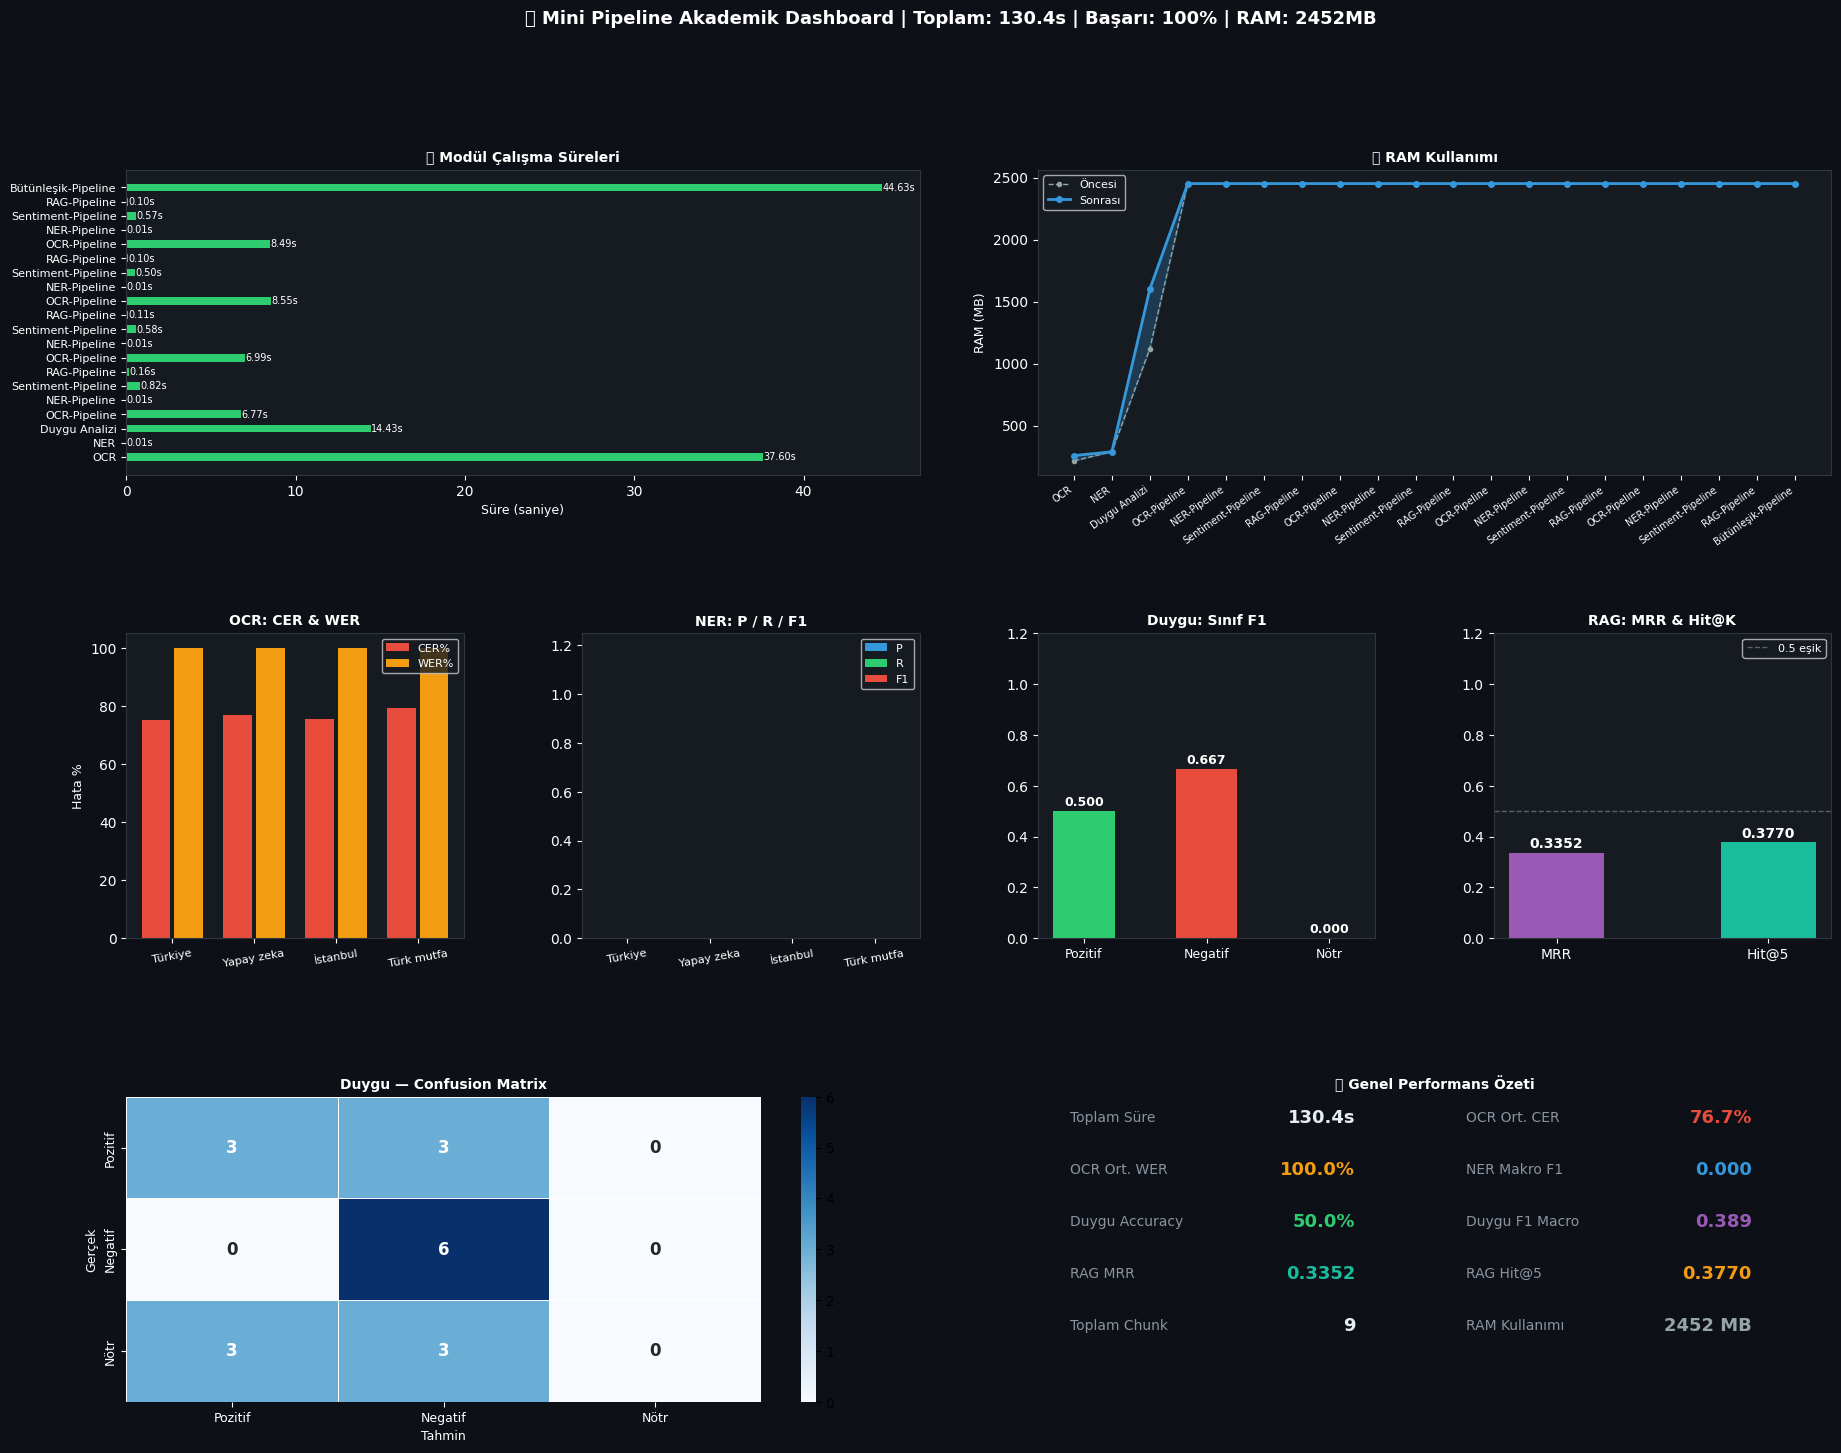

✅ Final dashboard kaydedildi


In [19]:
# ── BÖLÜM 6 — Akademik Performans Dashboardu ────────────────────────────────
# Tüm pipeline boyunca toplanan metrikler 8 panelde görselleştirilir

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np


VALID_M = [
    m for m in ALL_METRICS
    if m.duration is not None and m.success
]

fig = plt.figure(figsize=(22, 16))

fig.patch.set_facecolor("#0d1117")

gs = gridspec.GridSpec(
    3,
    4,
    figure=fig,
    hspace=0.52,
    wspace=0.35,
)

# =========================================================
# 1. MODÜL SÜRELERİ
# =========================================================

ax1 = fig.add_subplot(gs[0, 0:2])

ax1.set_facecolor("#161b22")

module_names = [
    m.name[:22] + ("…" if len(m.name) > 22 else "")
    for m in VALID_M
]

durations = [m.duration for m in VALID_M]

colors_d = [
    "#2ecc71" if m.success else "#e74c3c"
    for m in VALID_M
]

y_pos = range(len(module_names))

bars = ax1.barh(
    y_pos,
    durations,
    color=colors_d,
    edgecolor="none",
    height=0.55,
)

ax1.set_yticks(y_pos)

ax1.set_yticklabels(
    module_names,
    color="white",
    fontsize=8,
)

ax1.set_xlabel(
    "Süre (saniye)",
    color="white",
    fontsize=9,
)

ax1.set_title(
    "⏱ Modül Çalışma Süreleri",
    color="white",
    fontweight="bold",
    fontsize=10,
)

ax1.tick_params(colors="white")

for spine in ax1.spines.values():
    spine.set_color("#30363d")

for bar, d in zip(bars, durations):

    ax1.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{d:.2f}s",
        va="center",
        color="white",
        fontsize=7,
    )

# =========================================================
# 2. RAM KULLANIMI
# =========================================================

ax2 = fig.add_subplot(gs[0, 2:])

ax2.set_facecolor("#161b22")

ram_b = [m.ram_before for m in VALID_M]
ram_a = [m.ram_after for m in VALID_M]

xr = range(len(VALID_M))

ax2.fill_between(
    xr,
    ram_b,
    ram_a,
    alpha=0.25,
    color="#3498db",
)

ax2.plot(
    xr,
    ram_b,
    "o--",
    color="#95a5a6",
    markersize=3,
    lw=1,
    label="Öncesi",
)

ax2.plot(
    xr,
    ram_a,
    "o-",
    color="#3498db",
    markersize=4,
    lw=2,
    label="Sonrası",
)

ax2.set_xticks(list(xr))

ax2.set_xticklabels(
    module_names,
    rotation=35,
    ha="right",
    color="white",
    fontsize=7,
)

ax2.set_ylabel(
    "RAM (MB)",
    color="white",
    fontsize=9,
)

ax2.set_title(
    "💾 RAM Kullanımı",
    color="white",
    fontweight="bold",
    fontsize=10,
)

ax2.tick_params(colors="white")

for spine in ax2.spines.values():
    spine.set_color("#30363d")

ax2.legend(
    facecolor="#161b22",
    labelcolor="white",
    fontsize=8,
)

# =========================================================
# 3. OCR — CER / WER
# =========================================================

ax3 = fig.add_subplot(gs[1, 0])

ax3.set_facecolor("#161b22")

doc_short = [
    d["title"][:10]
    for d in DOCUMENTS
]

cer_v = [
    r["cer"] * 100
    for r in ocr_results
]

wer_v = [
    r["wer"] * 100
    for r in ocr_results
]

x3 = np.arange(len(doc_short))

ax3.bar(
    x3 - 0.2,
    cer_v,
    0.35,
    label="CER%",
    color="#e74c3c",
    edgecolor="none",
)

ax3.bar(
    x3 + 0.2,
    wer_v,
    0.35,
    label="WER%",
    color="#f39c12",
    edgecolor="none",
)

ax3.set_xticks(x3)

ax3.set_xticklabels(
    doc_short,
    color="white",
    fontsize=8,
    rotation=10,
)

ax3.set_title(
    "OCR: CER & WER",
    color="white",
    fontweight="bold",
    fontsize=10,
)

ax3.tick_params(colors="white")

for spine in ax3.spines.values():
    spine.set_color("#30363d")

ax3.legend(
    facecolor="#161b22",
    labelcolor="white",
    fontsize=8,
)

ax3.set_ylabel(
    "Hata %",
    color="white",
    fontsize=9,
)

# =========================================================
# 4. NER — PRECISION / RECALL / F1
# =========================================================

ax4 = fig.add_subplot(gs[1, 1])

ax4.set_facecolor("#161b22")

prec_n = [
    m["precision"]
    for m in ner_eval["per_document"]
]

rec_n = [
    m["recall"]
    for m in ner_eval["per_document"]
]

f1_n = [
    m["f1"]
    for m in ner_eval["per_document"]
]

x4 = np.arange(len(doc_short))

ax4.bar(
    x4 - 0.25,
    prec_n,
    0.22,
    label="P",
    color="#3498db",
    edgecolor="none",
)

ax4.bar(
    x4,
    rec_n,
    0.22,
    label="R",
    color="#2ecc71",
    edgecolor="none",
)

ax4.bar(
    x4 + 0.25,
    f1_n,
    0.22,
    label="F1",
    color="#e74c3c",
    edgecolor="none",
)

ax4.set_xticks(x4)

ax4.set_xticklabels(
    doc_short,
    color="white",
    fontsize=8,
    rotation=10,
)

ax4.set_ylim(0, 1.25)

ax4.set_title(
    "NER: P / R / F1",
    color="white",
    fontweight="bold",
    fontsize=10,
)

ax4.tick_params(colors="white")

for spine in ax4.spines.values():
    spine.set_color("#30363d")

ax4.legend(
    facecolor="#161b22",
    labelcolor="white",
    fontsize=8,
)

# =========================================================
# 5. DUYGU — SINIF F1
# =========================================================

ax5 = fig.add_subplot(gs[1, 2])

ax5.set_facecolor("#161b22")

rpt = eval_result["report"]

cls = ["Pozitif", "Negatif", "Nötr"]

f1_s = [
    rpt[c]["f1-score"]
    for c in cls
]

clrs = [
    "#2ecc71",
    "#e74c3c",
    "#95a5a6",
]

bars5 = ax5.bar(
    cls,
    f1_s,
    color=clrs,
    edgecolor="none",
    width=0.5,
)

ax5.set_ylim(0, 1.2)

ax5.set_title(
    "Duygu: Sınıf F1",
    color="white",
    fontweight="bold",
    fontsize=10,
)

ax5.tick_params(colors="white")

for spine in ax5.spines.values():
    spine.set_color("#30363d")

ax5.set_xticklabels(
    cls,
    color="white",
    fontsize=9,
)

for b, v in zip(bars5, f1_s):

    ax5.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.02,
        f"{v:.3f}",
        ha="center",
        color="white",
        fontsize=9,
        fontweight="bold",
    )

# =========================================================
# 6. RAG — MRR + HIT@K
# =========================================================

ax6 = fig.add_subplot(gs[1, 3])

ax6.set_facecolor("#161b22")

rag_labels = [
    "MRR",
    f"Hit@{retrieval_eval['k']}",
]

rag_vals = [
    retrieval_eval["mrr"],
    retrieval_eval["hit_at_k"],
]

rag_clrs = [
    "#9b59b6",
    "#1abc9c",
]

bars6 = ax6.bar(
    rag_labels,
    rag_vals,
    color=rag_clrs,
    edgecolor="none",
    width=0.45,
)

ax6.set_ylim(0, 1.2)

ax6.axhline(
    0.5,
    color="white",
    ls="--",
    alpha=0.3,
    lw=1,
    label="0.5 eşik",
)

ax6.set_title(
    "RAG: MRR & Hit@K",
    color="white",
    fontweight="bold",
    fontsize=10,
)

ax6.tick_params(colors="white")

for spine in ax6.spines.values():
    spine.set_color("#30363d")

ax6.set_xticklabels(
    rag_labels,
    color="white",
    fontsize=10,
)

ax6.legend(
    facecolor="#161b22",
    labelcolor="white",
    fontsize=8,
)

for b, v in zip(bars6, rag_vals):

    ax6.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.02,
        f"{v:.4f}",
        ha="center",
        color="white",
        fontsize=10,
        fontweight="bold",
    )

# =========================================================
# 7. CONFUSION MATRIX
# =========================================================

ax7 = fig.add_subplot(gs[2, 0:2])

ax7.set_facecolor("#161b22")

cm = eval_result["cm"]

lbls = [
    "Pozitif",
    "Negatif",
    "Nötr",
]

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=lbls,
    yticklabels=lbls,
    ax=ax7,
    annot_kws={
        "size": 12,
        "fontweight": "bold",
    },
    linewidths=0.5,
)

ax7.set_xlabel(
    "Tahmin",
    color="white",
    fontsize=9,
)

ax7.set_ylabel(
    "Gerçek",
    color="white",
    fontsize=9,
)

ax7.set_title(
    "Duygu — Confusion Matrix",
    color="white",
    fontweight="bold",
    fontsize=10,
)

ax7.tick_params(
    colors="white",
    labelsize=9,
)

# =========================================================
# 8. GENEL ÖZET
# =========================================================

ax8 = fig.add_subplot(gs[2, 2:])

ax8.set_facecolor("#161b22")

ax8.axis("off")

summary_items = [
    ("Toplam Süre", f"{sum(durations):.1f}s", "#e6edf3"),
    ("OCR Ort. CER", f"{np.mean(cer_v):.1f}%", "#e74c3c"),
    ("OCR Ort. WER", f"{np.mean(wer_v):.1f}%", "#f39c12"),
    ("NER Makro F1", f"{ner_eval['macro_f1']:.3f}", "#3498db"),
    ("Duygu Accuracy", f"{eval_result['accuracy'] * 100:.1f}%", "#2ecc71"),
    ("Duygu F1 Macro", f"{eval_result['f1_macro']:.3f}", "#9b59b6"),
    ("RAG MRR", f"{retrieval_eval['mrr']:.4f}", "#1abc9c"),
    (
        f"RAG Hit@{retrieval_eval['k']}",
        f"{retrieval_eval['hit_at_k']:.4f}",
        "#f39c12",
    ),
    ("Toplam Chunk", f"{len(rag.chunks)}", "#e6edf3"),
    ("RAM Kullanımı", f"{ram_mb():.0f} MB", "#95a5a6"),
]

cols = [
    (0.04, 0.40),
    (0.54, 0.90),
]

for i, (label, value, clr) in enumerate(summary_items):

    col = i % 2
    row = i // 2

    ypos = 0.93 - row * 0.17

    ax8.text(
        cols[col][0],
        ypos,
        label,
        transform=ax8.transAxes,
        color="#8b949e",
        fontsize=10,
        va="center",
    )

    ax8.text(
        cols[col][1],
        ypos,
        value,
        transform=ax8.transAxes,
        color=clr,
        fontsize=13,
        fontweight="bold",
        va="center",
        ha="right",
    )

ax8.set_title(
    "📋 Genel Performans Özeti",
    color="white",
    fontweight="bold",
    fontsize=10,
)

# =========================================================
# FİNAL
# =========================================================

total_time = sum(durations)

success_rate = (
    sum(1 for m in ALL_METRICS if m.success)
    / max(len(ALL_METRICS), 1)
    * 100
)

fig.suptitle(
    f"📊 Mini Pipeline Akademik Dashboard | "
    f"Toplam: {total_time:.1f}s | "
    f"Başarı: {success_rate:.0f}% | "
    f"RAM: {ram_mb():.0f}MB",
    color="white",
    fontsize=13,
    fontweight="bold",
)

plt.savefig(
    BASE / "output" / "final_dashboard.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)

plt.show()

print("✅ Final dashboard kaydedildi")

## 📋 BÖLÜM 7 — Özet Rapor & Çıktı Dosyaları

Pipeline tamamlandığında üretilen çıktı dosyaları listelenir ve tüm modüllerin temel metrikleri konsola yazdırılır:

- **OCR Ort. CER / WER** — karakter ve kelime hata oranları
- **NER Makro F1 / Precision / Recall** — varlık tanıma doğruluğu
- **Duygu Accuracy / F1 Macro** — duygu sınıflandırma performansı
- **RAG MRR / Hit@K** — retrieval kalitesi
- **Toplam chunk sayısı, çalışma süresi, RAM kullanımı**


In [20]:
# ── BÖLÜM 7 — Özet Rapor & Çıktı Dosyaları ─────────────────────────────────

import os

print("\n" + "═" * 65)

print(
    "🏁 HAFTA 9–10 BÜTÜNLEŞİK "
    "MİNİ PIPELINE — TAMAMLANDI"
)

print("═" * 65)

out_files = sorted(
    (BASE / "output").glob("*")
)

print(
    f"\n📁 ÇIKTI DOSYALARI "
    f"({len(out_files)} adet):"
)

for f in out_files:

    kb = f.stat().st_size / 1024

    print(
        f" ✅ {f.name:<45} "
        f"({kb:.1f} KB)"
    )

print("\n📊 ÖZET METRİKLER:")

print(
    f" OCR Ort. CER : "
    f"{np.mean([r['cer'] for r in ocr_results]):.3f}"
)

print(
    f" OCR Ort. WER : "
    f"{np.mean([r['wer'] for r in ocr_results]):.3f}"
)

print(
    f" NER Makro F1 : "
    f"{ner_eval['macro_f1']:.3f}"
)

print(
    f" NER Makro Precision : "
    f"{ner_eval['macro_precision']:.3f}"
)

print(
    f" NER Makro Recall : "
    f"{ner_eval['macro_recall']:.3f}"
)

print(
    f" Duygu Accuracy : "
    f"{eval_result['accuracy'] * 100:.1f}%"
)

print(
    f" Duygu F1 (Macro) : "
    f"{eval_result['f1_macro']:.3f}"
)

print(
    f" RAG MRR : "
    f"{retrieval_eval['mrr']:.4f}"
)

print(
    f" RAG Hit@{retrieval_eval['k']} : "
    f"{retrieval_eval['hit_at_k']:.4f}"
)

print(
    f" Toplam chunk sayısı : "
    f"{len(rag.chunks)}"
)

print(
    f" Toplam çalışma süresi : "
    f"{sum(m.duration for m in ALL_METRICS if m.duration):.1f}s"
)

print(
    f" Son RAM kullanımı : "
    f"{ram_mb():.0f} MB"
)

print(f"\n{'═' * 65}")

gc.collect()


═════════════════════════════════════════════════════════════════
🏁 HAFTA 9–10 BÜTÜNLEŞİK MİNİ PIPELINE — TAMAMLANDI
═════════════════════════════════════════════════════════════════

📁 ÇIKTI DOSYALARI (6 adet):
 ✅ final_dashboard.png                           (316.5 KB)
 ✅ ner_dashboard.png                             (123.3 KB)
 ✅ ocr_metrics.png                               (96.7 KB)
 ✅ ocr_preprocessing.png                         (243.2 KB)
 ✅ pipeline_report_20260514_0836.json            (9.7 KB)
 ✅ sentiment_dashboard.png                       (169.5 KB)

📊 ÖZET METRİKLER:
 OCR Ort. CER : 0.767
 OCR Ort. WER : 1.000
 NER Makro F1 : 0.000
 NER Makro Precision : 0.000
 NER Makro Recall : 0.000
 Duygu Accuracy : 50.0%
 Duygu F1 (Macro) : 0.389
 RAG MRR : 0.3352
 RAG Hit@5 : 0.3770
 Toplam chunk sayısı : 9
 Toplam çalışma süresi : 130.4s
 Son RAM kullanımı : 2475 MB

═════════════════════════════════════════════════════════════════


16940